# Deep Learning Project 2025
## Enrico Ferrari and Sebastiano Turco




# Introduction
In this project, we explored scalable and efficient strategies to fine-tune the CLIP model without modifying too much its original architecture. Our primary goal was to adapt CLIP to new tasks while preserving its strong zero-shot capabilities, avoiding full model retraining or excessive parameter tuning.

We began by investigating Parameter-Efficient Fine-Tuning (PEFT) techniques commonly used for large models like CLIP. In particular, we focused on the following approaches:

- Fine-tuning the projection layers,
- Fine-tuning the LayerNorm parameters,
- Adding a CLIP-Adapter module on top of the frozen CLIP backbone and training only the adapter.

These baseline methods allowed us to study the performance trade-offs and helped us identify a critical limitation: their tendency to overfit to base classes, leading to poor generalization on novel classes. This observation motivated us to look for ways to constrain the fine-tuning process and prevent such specialization.

To address this, we introduced a regularization mechanism based on distillation. Specifically, we added a loss term that penalizes deviations from the original CLIP model's predictions. This acts as a soft constraint, guiding the fine-tuned model to stay aligned with the original zero-shot behavior while still learning task-specific adaptations.

This distillation-enhanced approach offers a lightweight and effective way to improve simple PEFT techniques, giving us fine-grained control over the balance between adaptation and generalization.

Finally, we also experimented with ensemble methods, where different fine-tuned CLIP models—each trained with varying data splits—contribute to the final prediction. Certain classes were used exclusively for distillation, serving as surrogates for unseen or novel classes.

# CLIP Setting

In this first part we report a similar code to the one presented in the assignment project notebook.

In particular, this code splits the dataset into base and novel categories and runs the zero-shot evaluation with CLIP.

In [ ]:
%pip install openai_clip

In [ ]:
import torch
import torchvision
import torch.nn as nn
import clip
from tqdm import tqdm
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import Sampler
import argparse
import torchvision.transforms as transforms
from torch.utils.data import Dataset
from torch.optim import Adam
import random
import numpy as np
import copy
import math
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

## Dataset Loading
Let's get the data directly from torchvision as we have seen during labs.

In [ ]:
def get_data(data_dir="./data", transform=None):
    """Load Flowers102 train, validation and test sets.
    Args:
        data_dir (str): Directory where the dataset will be stored.
        transform (torch.Compose)
    Returns:
        tuple: A tuple containing the train, validation, and test sets.
    """
    train = torchvision.datasets.Flowers102(root=data_dir, split="train", download=True, transform=transform)
    val = torchvision.datasets.Flowers102(root=data_dir, split="val", download=True, transform=transform)
    test = torchvision.datasets.Flowers102(root=data_dir, split="test", download=True, transform=transform)
    return train, val, test

## Base and Novel categories
To split in base and novel categories we list all dataset classes, and count their number (we already know it's 102 but let's do it properly).
Then, we just allocate the first half to base categories and the remaining half to novel ones.
We can do this because we are simulating a real world application, but keep in mind this will not happen out there!

In [ ]:
def base_novel_categories(dataset):
    # set returns the unique set of all dataset classes
    all_classes = set(dataset._labels)
    # and let's count them
    num_classes = len(all_classes)

    # here list(range(num_classes)) returns a list from 0 to num_classes - 1
    # then we slice the list in half and generate base and novel category lists
    base_classes = list(range(num_classes))[:num_classes//2]
    novel_classes = list(range(num_classes))[num_classes//2:]
    return base_classes, novel_classes

## Inspect Classes
Let's now visualize which are the base and novel classes.
To do so, we first get a dummy test set (without augmentations) as we are just interested in the dataset labels. Then, we split it useing `base_novel_categories`.
Finally, we use the hard-coded CLASS_NAMES to print the class in natural language.

> Note: the list of class names was only recently added to `torchvision.datasets.Flowers102`. To avoid useless errors that can occour to you, we decided to also provide such a list.

In [ ]:
from os import name
_, _, tmp_test = get_data()
base_classes, novel_classes = base_novel_categories(tmp_test)
CLASS_NAMES = ["pink primrose", "hard-leaved pocket orchid", "canterbury bells", "sweet pea", "english marigold", "tiger lily", "moon orchid", "bird of paradise", "monkshood", "globe thistle", "snapdragon", "colt's foot", "king protea", "spear thistle", "yellow iris", "globe-flower", "purple coneflower", "peruvian lily", "balloon flower", "giant white arum lily", "fire lily", "pincushion flower", "fritillary", "red ginger", "grape hyacinth", "corn poppy", "prince of wales feathers", "stemless gentian", "artichoke", "sweet william", "carnation", "garden phlox", "love in the mist", "mexican aster", "alpine sea holly", "ruby-lipped cattleya", "cape flower", "great masterwort", "siam tulip", "lenten rose", "barbeton daisy", "daffodil", "sword lily", "poinsettia", "bolero deep blue", "wallflower", "marigold", "buttercup", "oxeye daisy", "common dandelion", "petunia", "wild pansy", "primula", "sunflower", "pelargonium", "bishop of llandaff", "gaura", "geranium", "orange dahlia", "pink-yellow dahlia?", "cautleya spicata", "japanese anemone", "black-eyed susan", "silverbush", "californian poppy", "osteospermum", "spring crocus", "bearded iris", "windflower", "tree poppy", "gazania", "azalea", "water lily", "rose", "thorn apple", "morning glory", "passion flower", "lotus", "toad lily", "anthurium", "frangipani", "clematis", "hibiscus", "columbine", "desert-rose", "tree mallow", "magnolia", "cyclamen", "watercress", "canna lily", "hippeastrum", "bee balm", "ball moss", "foxglove", "bougainvillea", "camellia", "mallow", "mexican petunia", "bromelia", "blanket flower", "trumpet creeper", "blackberry lily"]
print("Base Class Names:", [(i, CLASS_NAMES[i]) for i in base_classes])
name_base = [CLASS_NAMES[i] for i in base_classes]
name_novel = [CLASS_NAMES[i] for i in novel_classes]
print("Novel Class Names:", [(i, CLASS_NAMES[i]) for i in novel_classes])

Base Class Names: [(0, 'pink primrose'), (1, 'hard-leaved pocket orchid'), (2, 'canterbury bells'), (3, 'sweet pea'), (4, 'english marigold'), (5, 'tiger lily'), (6, 'moon orchid'), (7, 'bird of paradise'), (8, 'monkshood'), (9, 'globe thistle'), (10, 'snapdragon'), (11, "colt's foot"), (12, 'king protea'), (13, 'spear thistle'), (14, 'yellow iris'), (15, 'globe-flower'), (16, 'purple coneflower'), (17, 'peruvian lily'), (18, 'balloon flower'), (19, 'giant white arum lily'), (20, 'fire lily'), (21, 'pincushion flower'), (22, 'fritillary'), (23, 'red ginger'), (24, 'grape hyacinth'), (25, 'corn poppy'), (26, 'prince of wales feathers'), (27, 'stemless gentian'), (28, 'artichoke'), (29, 'sweet william'), (30, 'carnation'), (31, 'garden phlox'), (32, 'love in the mist'), (33, 'mexican aster'), (34, 'alpine sea holly'), (35, 'ruby-lipped cattleya'), (36, 'cape flower'), (37, 'great masterwort'), (38, 'siam tulip'), (39, 'lenten rose'), (40, 'barbeton daisy'), (41, 'daffodil'), (42, 'sword 

## Split Dataset
The next step is to actually split the dataset into the base and novel categories we extract from `base_novel_categories`.
To split the data we need the dataset (obviously) and the list of base classes. If the sample label is not part of the base categories, then it must be part of the novel ones.

In [ ]:
def split_data(dataset, base_classes):
    # these two lists will store the sample indexes
    base_categories_samples = []
    novel_categories_samples = []

    # we create a set of base classes to compute the test below in O(1)
    # this is optional and can be removed
    base_set = set(base_classes)

    # here we iterate over sample labels and also get the correspondent sample index
    for sample_id, label in enumerate(dataset._labels):
        if label in base_set:
            base_categories_samples.append(sample_id)
        else:
            novel_categories_samples.append(sample_id)

    # here we create the dataset subsets
    # the torch Subset is just a wrapper around the dataset
    # it simply stores the subset indexes and the original dataset (your_subset.dataset)
    # when asking for sample i in the subset, torch will look for its original position in the dataset and retrieve it
    # https://pytorch.org/docs/stable/data.html#torch.utils.data.Subset
    base_dataset = torch.utils.data.Subset(dataset, base_categories_samples)
    novel_dataset = torch.utils.data.Subset(dataset, novel_categories_samples)
    return base_dataset, novel_dataset

## Load CLIP

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/16", device=device)
model = model.float()
logit_scale = model.logit_scale

In [ ]:
# get the three datasets
train_set, val_set, test_set = get_data(transform=preprocess)

# split classes into base and novel
base_classes, novel_classes = base_novel_categories(train_set)
print(base_classes)

# split the three datasets
train_base, _ = split_data(train_set, base_classes)
val_base, _ = split_data(val_set, base_classes)
test_base, test_novel = split_data(test_set, base_classes)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


## Compute Zero-Shot Predictions

We define the function we'll use for evaluating the CLIP model. We slightly modified the original function of the assignment notebook including the possibility of computing the accuracy for every single class, and returning the whole confusion matrix.

In [ ]:
@torch.no_grad()
def eval(model, dataset, categories, batch_size, device, label="", text_inputs=None):
    model.eval()

    # Mappa le etichette in un set contiguo di indici
    contig_cat2idx = {cat: idx for idx, cat in enumerate(categories)}
    num_classes = len(categories)

    # Tokenizzazione e encoding del testo
    if text_inputs is None:
        text_inputs = clip.tokenize(
            [f"a photo of a {CLASS_NAMES[c]}, a type of flower." for c in categories]
        ).to(device)
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Dataloader
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Variabili per accuracy e confusion matrix
    correct_predictions = 0
    total_per_class = [0] * num_classes
    correct_per_class = [0] * num_classes

    all_targets = []
    all_predictions = []

    for image, target in dataloader:
        # Mappa le classi in indici contigui
        target = torch.Tensor([contig_cat2idx[t.item()] for t in target]).long()

        image = image.to(device)
        target = target.to(device)

        # Estrai feature immagine e normalizza
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # Predizione via similarità coseno
        predicted_class = (image_features @ text_features.T).argmax(dim=-1)

        # Salva predizioni e target per la confusion matrix
        all_predictions.extend(predicted_class.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

        # Accuracy globale
        correct_predictions += (predicted_class == target).sum().item()

        # Accuracy per classe
        for t, p in zip(target, predicted_class):
            total_per_class[t.item()] += 1
            if t == p:
                correct_per_class[t.item()] += 1

    # Calcolo accuracies
    total_samples = sum(total_per_class)
    overall_accuracy = correct_predictions / total_samples

    per_class_accuracy = [
        correct / total if total > 0 else 0.0
        for correct, total in zip(correct_per_class, total_per_class)
    ]

    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_predictions, labels=list(range(num_classes)))

    return overall_accuracy, per_class_accuracy, cm

In [ ]:
def harmonic_mean(base_accuracy, novel_accuracy):
    numerator = 2
    denominator = 1 / base_accuracy + 1 / novel_accuracy
    hm = numerator / denominator
    return hm

In [ ]:
performance_measures = ["Base acc", "Novel acc", "Harmonic mean"]

Here we implement the function to plot the confusion matrix.

In [ ]:
def plot_confusion_matrix(cm, ax, dataset):

    # Normalize per row
    with np.errstate(all='ignore'):
        cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        cm_normalized = np.nan_to_num(cm_normalized)

    sns.heatmap(cm_normalized, annot=False, cmap='Reds', cbar=True, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"Confusion Matrix for {dataset}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([])
    ax.set_yticks([])

def truncate(x, decimals=3):
    factor = 10 ** decimals
    return np.trunc(x * factor) / factor

We compute the base and novel accuracies of CLIP on test set. Then, we compute the harmonic mean of the two.

In [ ]:
model, _ = clip.load("ViT-B/16", device=device)

base_accuracy, _, cm1 = eval(model=model, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracy, _, cm2 = eval(model=model, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")

print()
print(f"🔍 Base classes accuracy: {base_accuracy*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracy*100:.2f}%")
print(f"🔍 Harmonic Mean: {harmonic_mean(base_accuracy, novel_accuracy)*100:.2f}%")

🧠 Zero-shot evaluation on Novel Classes: 100%|██████████| 29/29 [00:16<00:00,  1.80it/s]


🔍 Base classes accuracy: 71.33%
🔍 Novel classes accuracy: 78.24%
🔍 Harmonic Mean: 74.62%


Lastly, we report the confusion matrices associated to these two predictions.

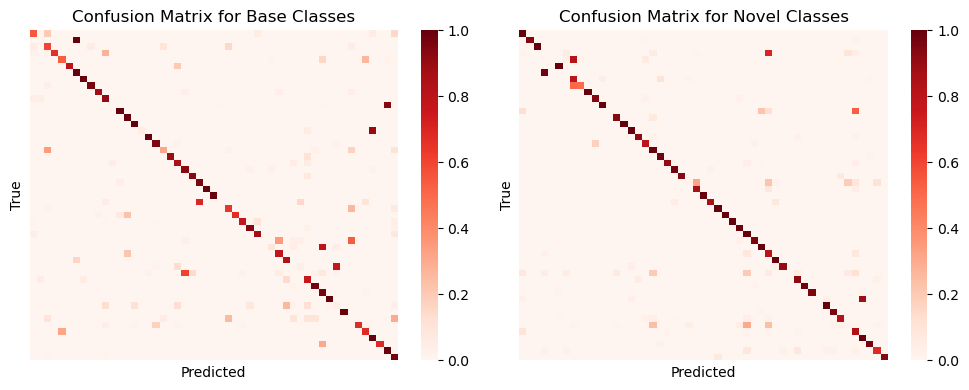

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_confusion_matrix(cm1, ax=axes[0], dataset="Base Classes")
plot_confusion_matrix(cm2, ax=axes[1], dataset="Novel Classes")

plt.tight_layout()
plt.show()

# Data Augmentation

We use a data-augmentation on training set for enhancing variability and size of our dataset.
For reproducibility of our experiments, we fix the seed for the random transformations of images. We'll use simple transformations that will preserve the main features of the flowers. In particular, they are:
- Solarizing
- Flopping
- Rotating
- Cropping
- Random noise

In [ ]:
def set_seed(seed):

    """
    function to set the seed for reproducibility
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class AddGaussianNoise(torch.nn.Module):

    """
    class to add gaussian noise to the images
    """
    def __init__(self, mean=0., std=0.05):
        super().__init__()
        self.mean = mean
        self.std = std

    def forward(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

def get_transforms(seed):

    """
    function to return a transformation of data with fixed seed
    """
    set_seed(seed)

    augmentation_transforms = transforms.Compose([
        transforms.RandomSolarize(0.5, p=0.1),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
        AddGaussianNoise(mean=0., std=0.02),
    ])

    return augmentation_transforms

class AugmentedDataset(Dataset):

    """
    class for augmenting the dataset
    """
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, label = self.data[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
def get_dataloader(dataset, batch_size, shuffle, num_workers, seed):

    """
    returns a reproducible DataLoader  for the given dataset
    """
    generator = torch.Generator()
    generator.manual_seed(seed)

    def worker_init_fn(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
        torch.manual_seed(worker_seed)

    return torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        worker_init_fn=worker_init_fn,
        generator=generator if shuffle else None
    )

For our experiments we have chosen a batch size of $16$, since the scarcity of the data. Then, we set a seed for reproducibility of results, not only on the transformations but also on the dataloader.

In [ ]:
batch_size = 16
seed = 42
set_seed(seed)
augmentation_transforms = get_transforms(seed)
augmented_train_base = AugmentedDataset(data = train_base, transform = augmentation_transforms)

# Baselines

In this section, we implement several baseline approaches based on Parameter-Efficient Fine-Tuning (PEFT), including CLIP-Adapter, LayerNorm fine-tuning, and conventional fine-tuning of the text and visual projection layers. These baselines are essential for understanding the limitations of naive fine-tuning strategies in few-shot adaptation scenarios, especially when our goal is to retain CLIP's strong generalization to novel classes. As we will see, these models tend to overfit to the base classes, resulting in a significant loss of the pretrained CLIP model’s zero-shot capabilities, an outcome we aim to mitigate.


# CLIP-Adapter

Unlike prompt learning methods, **CLIP-Adapter** aims to fine-tune either the visual or language branch of CLIP using a simple and lightweight architecture. Following the original paper "CLIP-Adapter: Better Vision-Language Models with Feature Adapters", we extend the visual and language encoders by appending additional bottleneck layers designed to learn task-specific features.

The key idea is to add a lightweight MLP on top of CLIP to reduce the number of trainable parameters, thereby mitigating overfitting in few-shot scenarios. To further preserve CLIP’s original behavior, the adapter integrates residual-style feature blending of the form:

$$
\alpha x + (1 - \alpha) f(x)
$$

where $\alpha$ is a learnable scalar parameter.

In addition to the original design, we introduce a variant where the blending coefficient $\alpha(x)$ is itself predicted by an MLP conditioned on the input—specifically, the encoding of the image-text pair being processed. This modification is intended to improve generalization on unseen classes by adaptively balancing CLIP’s zero-shot representations with task-specific refinements.

However, in our experiments, we did not observe significant differences in performance between the two versions. We hypothesize that the adaptive $\alpha(x)$ struggles to reliably distinguish between examples where CLIP already performs well and those that require adaptation. For this reason, we report results using the simpler version, where $\alpha$ is a single learnable scalar.

Additionally, we explored various configurations of the adapter:

- Applying separate adapters to the visual and text branches  
- Applying the adapter to only one branch (visual or text)  
- Using a shared adapter for both branches to promote interaction between modalities

The architectures of the MLP used for CLIP-Adapter are lightweight networks, that we've taken from the original paper.
Among these models, the shared adapter configuration with the learnable $\alpha$ parameter yielded the most promising results, and thus we focus only on this variant in our final evaluations.



In [ ]:
class ResidualAdapter(nn.Module):
    """ class that defines the bottleneck MLP that will be used on top of CLIP"""

    def __init__(self, dim):
        super().__init__()
        #we define first the MLP for the blending parameter
        #the choice of Dropout was for reducing overfitting
        self.alpha_mlp = nn.Sequential(
            nn.Linear(dim, dim//4),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(dim//4, dim//16),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(dim//16, 1),
            nn.Sigmoid()
        )
        #bottleneck MLP that will stand on top of CLIP encoders
        self.fc = nn.Sequential(
            nn.Linear(512, 512 // 4, bias=False),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(512 // 4, 512, bias=False),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        alpha = self.alpha_mlp(x)
        adapted = self.fc(x)
        # Blend original features and adapted features
        return alpha * x + (1.0 - alpha) * adapted

class ResidualAdapter_classic(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(512, 512 // 4, bias=False),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(512 // 4, 512, bias=False),
            nn.ReLU(inplace=True)
        )

        self.alpha = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        alpha = torch.sigmoid(self.alpha)
        return alpha*x + (1.0 - alpha)*self.fc(x)

class CLIPWithAdapter(nn.Module):

    """
  class of our final model that will be finetuned:
    -it takes as argument the pretrained CLIP and adds on top of it the additional MLP
    -we can choose if adding a different MLP on text and visual branch,
     or instead use the same for promoting communication between branches
    - the argument mode is for choosing the model where alpha is a learnable parameter or
      it is the output of a small MLP
    """

    def __init__(self, clip_model, mode):
        super().__init__()
        self.clip = clip_model
        if mode == 0:
          self.adapter = ResidualAdapter_classic(clip_model.visual.output_dim)
        else:
          self.adapter = ResidualAdapter(clip_model.visual.output_dim)

    def encode_image(self, image):
        with torch.no_grad():
            img_feat = self.clip.encode_image(image)
        img_feat = self.adapter(img_feat)

        return img_feat

    def encode_text(self, text):
        with torch.no_grad():
          txt_feat = self.clip.encode_text(text)
        txt_feat = self.adapter(txt_feat)

        return txt_feat

    def forward(self, image, text):
        image_features = self.encode_image(image)
        text_features = self.encode_text(text)
        return image_features, text_features

# Fine-tuning
In the following cells we will define the function that will be responsible for the finetuning of CLIP, based on the different finetuning strategies.
In particular we choose a learning rate of $lr = 1e-4$ for finetuning of projection layers, whereas slightly higher for CLIP-adapter and  LN, $0.0005$.
The choice of learning rate and number of epochs was chosen by hyperparameter tuning.

In [ ]:
def get_trainable_parameters(model, tuning_options):
            """function to construct a list of parameters that  will be used in the finetuning """

            trainable_parameters = []

            if "visual" in tuning_options: #finetuning the visual projection layer
                trainable_parameters.append(model.visual.proj)

            if "text" in tuning_options: #finetuning the text projection layer
                trainable_parameters.append(model.text_projection)

            if "layer norm" in tuning_options: #finetuning layer norm parameters
                bn_params = [
                    param for name, param in model.named_parameters()
                    if "ln" in name
                ]
                trainable_parameters.extend(bn_params)

            return trainable_parameters

parameters_names = ["visual", "text", "layer norm", "CLIP-adapter"]

In [ ]:
def ft(model, trainable_parameters, train_dataloader, val_dataloader, categories, lr, wd, num_epochs, device, novel_computation=False, text_inputs=None, alpha_adapter=False):

  """
  function to fine-tune the model:
  the stoppage criterium will be based on the validation accuracy
  takes in input:
  - model: clip or clip_adapter
  - trainable_parameters: a list of parameters that we will finetune, that will define the fine-tune strategy that we chose
  - train_dataloader: the dataloader for training
  - val_dataloader : the dataloader for validation
  - categories: list of indexes that correspond to  base classes
  - lr : learning rate
  - wd: weight decay
  - num_epochs: total number of epochs that we use
  - device: cuda or cpu
  - novel_computation: parameter for deciding if we should save the performance of the model during training on novel classes for the plots
  - text_inputs: if None we use the usual prompts
  - alpha_adapter : parameter for deciding if we should use a higher learning rate for alpha in CLIP-Adapter
  """

  model = model.float()

  # Freeze all parameters in the model
  for param in model.parameters():
      param.requires_grad = False

  # Unfreeze the trainable parameters
  for param in trainable_parameters:
    param.requires_grad = True

  # Use cross-entropy loss and Adam as optimizer
  criterion = torch.nn.CrossEntropyLoss()

  if alpha_adapter: #heuristically we would want that the alpha parameters learns faster than the bottleneck MLP,
                    #since the latter depends on the blending that the alpha_MLP produces

    params_with_different_lr = [
    {
        "params": [p for n, p in model.adapter.named_parameters() if "mlp" in n],
        "lr": lr * 2
    },
    {
        "params": [p for n, p in model.adapter.named_parameters() if "mlp" not in n],
        "lr": lr
    }
    ]

    optimizer = torch.optim.Adam(params_with_different_lr, weight_decay=wd)

  else:

    optimizer = Adam(trainable_parameters, lr=lr, weight_decay=wd)

  # Dictionary to assign an index (starting from 0) to each class name (of the base classes)
  contig_cat2idx = {cat: idx for idx, cat in enumerate(categories)}

  # Record the accuracy value
  saved_accuracy = torch.tensor(0.0)

  # Tokenization of the class names
  if text_inputs == None:
      text_inputs = clip.tokenize(
           [f"a photo of a {CLASS_NAMES[c]}, a type of flower." for c in categories]).to(device)

  if novel_computation == True:
      novel_acc = []
      train_acc = []
      val_acc = []

  print("🧠 Fine-tuning training+validation on Base Classes")

  # Training Loop

  for epoch in range(num_epochs):

    # Training

    model.train()
    # sum of all the computed losses through the all batches
    total_loss = 0
    # number of correct predictions
    correct_predictions = 0
    n_images = 0

    for image, target in train_dataloader:

          target = torch.Tensor([contig_cat2idx[t.item()] for t in target]).long()

          image = image.to(device).float()
          target = target.to(device)

          # compute text representation of the targets in the batch
          text_features = model.encode_text(text_inputs).float()
          # normalization
          text_features_norm = text_features.norm(dim=-1, keepdim=True)
          text_features = text_features/text_features_norm

          # compute visual representation of the images in the batch
          image_features = model.encode_image(image).float()
          # normalization
          image_features_norm = image_features.norm(dim=-1, keepdim=True)
          image_features = image_features/image_features_norm

          # cosine similarity between image and text features
          logits = logit_scale.exp() * image_features @ text_features.T

          # cross-entropy loss
          loss = criterion(logits, target)

          # backpropagation
          loss.backward()
          optimizer.step()
          optimizer.zero_grad()

          #lr_scheduler.step()

          # training accuracy computation
          total_loss += loss.item()
          predicted_class = logits.argmax(dim=-1)
          correct_predictions += (predicted_class == target).sum().item()
          n_images += len(target)

    train_accuracy = correct_predictions / n_images
    print(f"Epoch {epoch + 1}, Training accuracy: {train_accuracy*100:.2f}%")

    # Validation

    model.eval()
    total_loss = 0
    correct_predictions = 0
    n_images = 0

    with torch.no_grad():

        for image, target in val_dataloader:

          target = torch.Tensor([contig_cat2idx[t.item()] for t in target]).long()

          image = image.to(device).float()
          target = target.to(device)

          text_features = model.encode_text(text_inputs).float()
          text_features_norm = text_features.norm(dim=-1, keepdim=True)
          text_features = text_features/text_features_norm

          image_features = model.encode_image(image).float()
          image_features_norm = image_features.norm(dim=-1, keepdim=True)
          image_features = image_features/image_features_norm

          logits = logit_scale.exp() * image_features @ text_features.T

          loss = criterion(logits, target)
          total_loss += loss.item()

          # validation accuracy computation
          predicted_class = logits.argmax(dim=-1)
          correct_predictions += (predicted_class == target).sum().item()
          n_images += len(target)

    validation_accuracy = correct_predictions / n_images
    print(f"Epoch {epoch + 1}, Validation accuracy: {validation_accuracy*100:.2f}%")

    if novel_computation == True:
        novel_accuracy, _, _ = eval(model=model, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
        train_acc.append(train_accuracy)
        val_acc.append(validation_accuracy)
        novel_acc.append(novel_accuracy)

    # update the highest accuracy, and save the relative model
    if validation_accuracy >= saved_accuracy:
      saved_accuracy = validation_accuracy
      saved_model = copy.deepcopy(model.state_dict())
      n_net = epoch

  # select the model by early-stoppage on validation accuracy
  print(f"selected net at epoch {n_net+1}")
  model.load_state_dict(saved_model)

  if novel_computation == True:
      return model, train_acc, val_acc, novel_acc
  else:
      return model

In the following code we test the baselines, computing the accuracy on test dataset for base and novel classes, and then the harmonic mean of the two.
We also save the accuracies for plotting the performance of the model at different moments of the training.

In [ ]:
base_accuracies_ft = {}
novel_accuracies_ft = {}
harmonic_means_ft = {}
cm_base_ft = {}
cm_novel_ft = {}

train_history_ft = {}
val_history_ft = {}
novel_history_ft = {}

for parameters_name in parameters_names[:3]:

  model, _ = clip.load("ViT-B/16", device=device)

  train_dataloader = get_dataloader(augmented_train_base, batch_size=batch_size, shuffle=True, num_workers=2, seed=seed)
  val_dataloader = get_dataloader(val_base, batch_size=batch_size, shuffle=False, num_workers=2, seed=seed)

  trainable_parameters = get_trainable_parameters(model, parameters_name)

  if parameters_name == "layer norm":
      lr = 0.0005
      wd = 0.0001
      num_epochs = 15
  else:
      lr = 0.0001
      wd = 0.0001
      num_epochs = 15

  model_ft, train_history_ft[parameters_name], val_history_ft[parameters_name], novel_history_ft[parameters_name] = ft(
                model = model,
                trainable_parameters = trainable_parameters,
                train_dataloader = train_dataloader,
                val_dataloader = val_dataloader,
                categories = base_classes,
                lr = lr,
                wd = wd,
                num_epochs = num_epochs,
                novel_computation = True,
                device=device)

  base_accuracies_ft[parameters_name], _, cm_base_ft[parameters_name] = eval(model=model_ft, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
  novel_accuracies_ft[parameters_name], _, cm_novel_ft[parameters_name]= eval(model=model_ft, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
  harmonic_means_ft[parameters_name] = harmonic_mean(base_accuracies_ft[parameters_name], novel_accuracies_ft[parameters_name])

  print(f"🔍 Base classes accuracy: {base_accuracies_ft[parameters_name]*100:.2f}%")
  print(f"🔍 Novel classes accuracy: {novel_accuracies_ft[parameters_name]*100:.2f}%")
  print(f"🔍 Harmonic Mean: {harmonic_means_ft[parameters_name] *100:.2f}%")

🧠 Fine-tuning training+validation on Base Classes
Epoch 1, Training accuracy: 63.14%
Epoch 1, Validation accuracy: 79.61%
Epoch 2, Training accuracy: 82.94%
Epoch 2, Validation accuracy: 90.59%
Epoch 3, Training accuracy: 89.80%
Epoch 3, Validation accuracy: 91.57%
Epoch 4, Training accuracy: 94.71%
Epoch 4, Validation accuracy: 92.94%
Epoch 5, Training accuracy: 94.12%
Epoch 5, Validation accuracy: 94.51%
Epoch 6, Training accuracy: 94.90%
Epoch 6, Validation accuracy: 94.71%
Epoch 7, Training accuracy: 96.08%
Epoch 7, Validation accuracy: 93.73%
Epoch 8, Training accuracy: 96.86%
Epoch 8, Validation accuracy: 95.10%
Epoch 9, Training accuracy: 96.86%
Epoch 9, Validation accuracy: 96.27%
Epoch 10, Training accuracy: 98.04%
Epoch 10, Validation accuracy: 96.08%
Epoch 11, Training accuracy: 96.67%
Epoch 11, Validation accuracy: 94.90%
Epoch 12, Training accuracy: 97.84%
Epoch 12, Validation accuracy: 95.29%
Epoch 13, Training accuracy: 98.43%
Epoch 13, Validation accuracy: 95.29%
Epoch 

In [ ]:
# adapter fine-tuning

clip_model, _ = clip.load("ViT-B/16", device=device)
clip_model = clip_model.float()
model = CLIPWithAdapter(clip_model, mode = 0)
model = model.to(device)
trainable_parameters = list(model.adapter.parameters())

train_dataloader = get_dataloader(augmented_train_base, batch_size=batch_size, shuffle=True, num_workers=2, seed=seed)
val_dataloader = get_dataloader(val_base, batch_size=batch_size, shuffle=False, num_workers=2, seed=seed)

parameters_name = "CLIP-adapter"

model_ft, train_history_ft[parameters_name], val_history_ft[parameters_name], novel_history_ft[parameters_name] = ft(
                model = model,
                trainable_parameters = trainable_parameters,
                train_dataloader = train_dataloader,
                val_dataloader = val_dataloader,
                categories = base_classes,
                lr = 0.0005,
                wd = 0.0001,
                num_epochs = 25,
                device=device,
                novel_computation = True,
                alpha_adapter=False)

base_accuracies_ft[parameters_name], _, cm_base_ft[parameters_name] = eval(model=model_ft, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracies_ft[parameters_name], _, cm_novel_ft[parameters_name]= eval(model=model_ft, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
harmonic_means_ft[parameters_name] = harmonic_mean(base_accuracies_ft[parameters_name], novel_accuracies_ft[parameters_name])

print(f"🔍 Base classes accuracy: {base_accuracies_ft[parameters_name]*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracies_ft[parameters_name]*100:.2f}%")
print(f"🔍 Harmonic Mean: {harmonic_means_ft[parameters_name] *100:.2f}%")

🧠 Fine-tuning training+validation on Base Classes
Epoch 1, Training accuracy: 59.41%
Epoch 1, Validation accuracy: 73.14%
Epoch 2, Training accuracy: 65.10%
Epoch 2, Validation accuracy: 73.33%
Epoch 3, Training accuracy: 65.88%
Epoch 3, Validation accuracy: 76.27%
Epoch 4, Training accuracy: 71.76%
Epoch 4, Validation accuracy: 77.25%
Epoch 5, Training accuracy: 74.51%
Epoch 5, Validation accuracy: 81.37%
Epoch 6, Training accuracy: 80.20%
Epoch 6, Validation accuracy: 84.90%
Epoch 7, Training accuracy: 83.92%
Epoch 7, Validation accuracy: 88.63%
Epoch 8, Training accuracy: 83.53%
Epoch 8, Validation accuracy: 89.22%
Epoch 9, Training accuracy: 85.69%
Epoch 9, Validation accuracy: 91.57%
Epoch 10, Training accuracy: 89.41%
Epoch 10, Validation accuracy: 91.96%
Epoch 11, Training accuracy: 90.20%
Epoch 11, Validation accuracy: 93.53%
Epoch 12, Training accuracy: 92.55%
Epoch 12, Validation accuracy: 92.55%
Epoch 13, Training accuracy: 91.57%
Epoch 13, Validation accuracy: 93.14%
Epoch 

In [ ]:
# save computed data

torch.save(base_accuracies_ft, "base_accuracies_ft.pt")
torch.save(novel_accuracies_ft, "novel_accuracies_ft.pt")
torch.save(harmonic_means_ft, "harmonic_means_ft.pt")
torch.save(cm_base_ft, "cm_base_ft.pt")
torch.save(cm_novel_ft, "cm_novel_ft.pt")
torch.save(train_history_ft, "train_history_ft.pt")
torch.save(val_history_ft, "val_history_ft.pt")
torch.save(novel_history_ft, "novel_history_ft.pt")

We report the accuracy of the fine-tuning baselines on the base and novel test set, and the harmonic mean of the two.
Then we report also the confusion matricies, the evolution of the accuracies on the validation and training set for base classes, and the test set for novel classes.

In [ ]:
# Print the metrics for each fine-tuning

rows = []
for param in parameters_names:
    row = {
        "Base Accuracy": base_accuracies_ft[param],
        "Novel Accuracy": novel_accuracies_ft[param],
        "Harmonic Mean": harmonic_means_ft[param]
    }
    rows.append(row)

df = pd.DataFrame(rows, index=parameters_names)
df = df.apply(lambda col: col.map(lambda x: f"{x * 100:.2f}%"))

print(df)

             Base Accuracy Novel Accuracy Harmonic Mean
visual              93.53%         68.69%        79.21%
text                95.35%         72.58%        82.42%
layer norm          92.40%         74.78%        82.66%
CLIP-adapter        94.34%         72.71%        82.13%


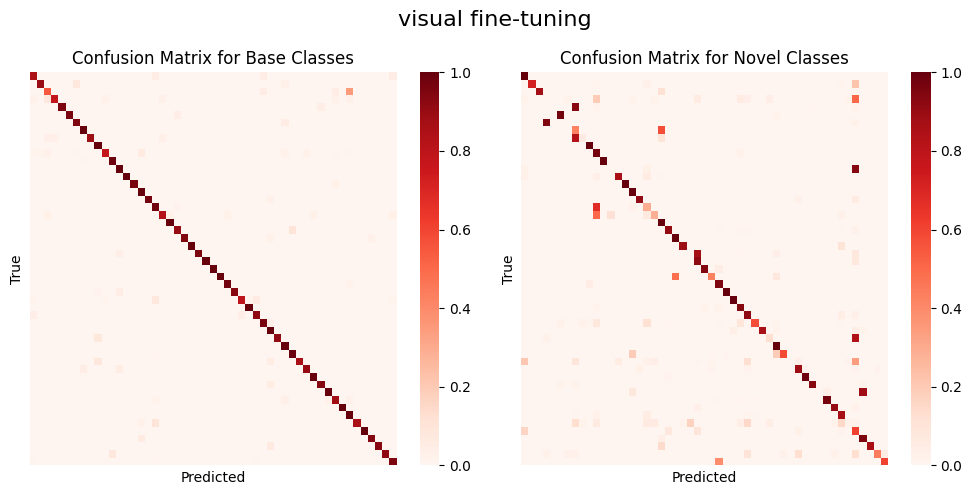

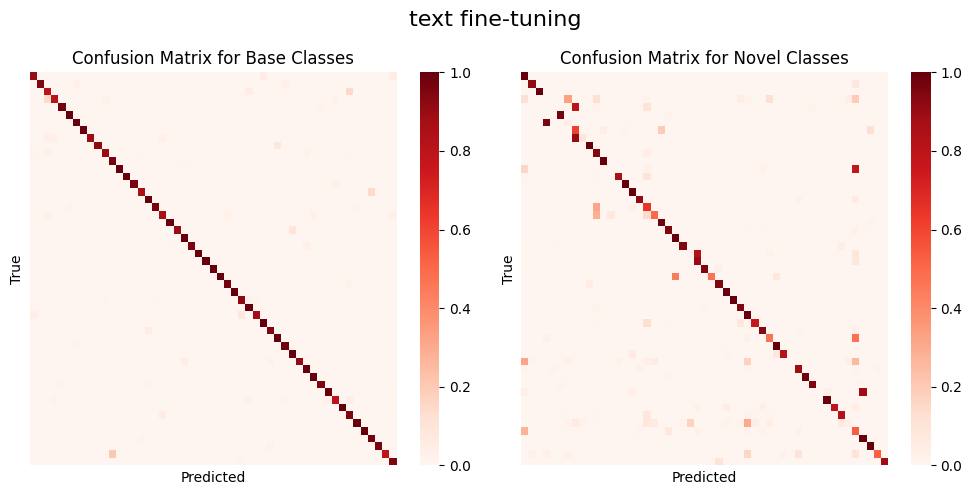

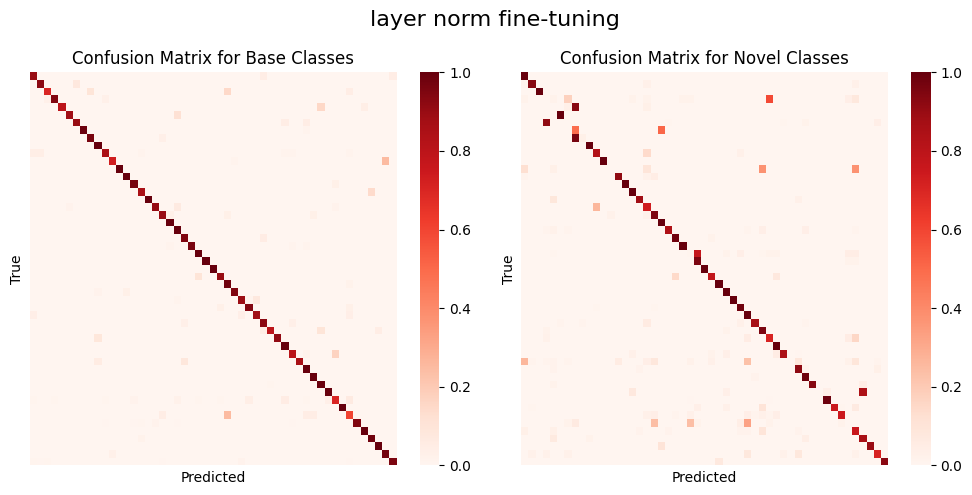

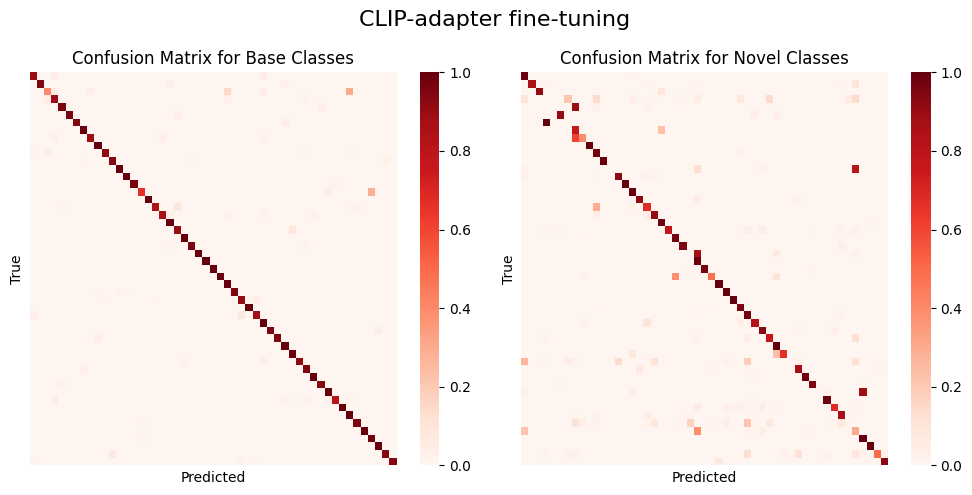

In [ ]:
# show confusion matrices on both base and novel test sets

for param_name in parameters_names:

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    plot_confusion_matrix(cm_base_ft[param_name], ax=axes[0], dataset="Base Classes")
    plot_confusion_matrix(cm_novel_ft[param_name], ax=axes[1], dataset="Novel Classes")

    fig.suptitle(f"{param_name} fine-tuning", fontsize=16)

    plt.tight_layout()
    plt.show()

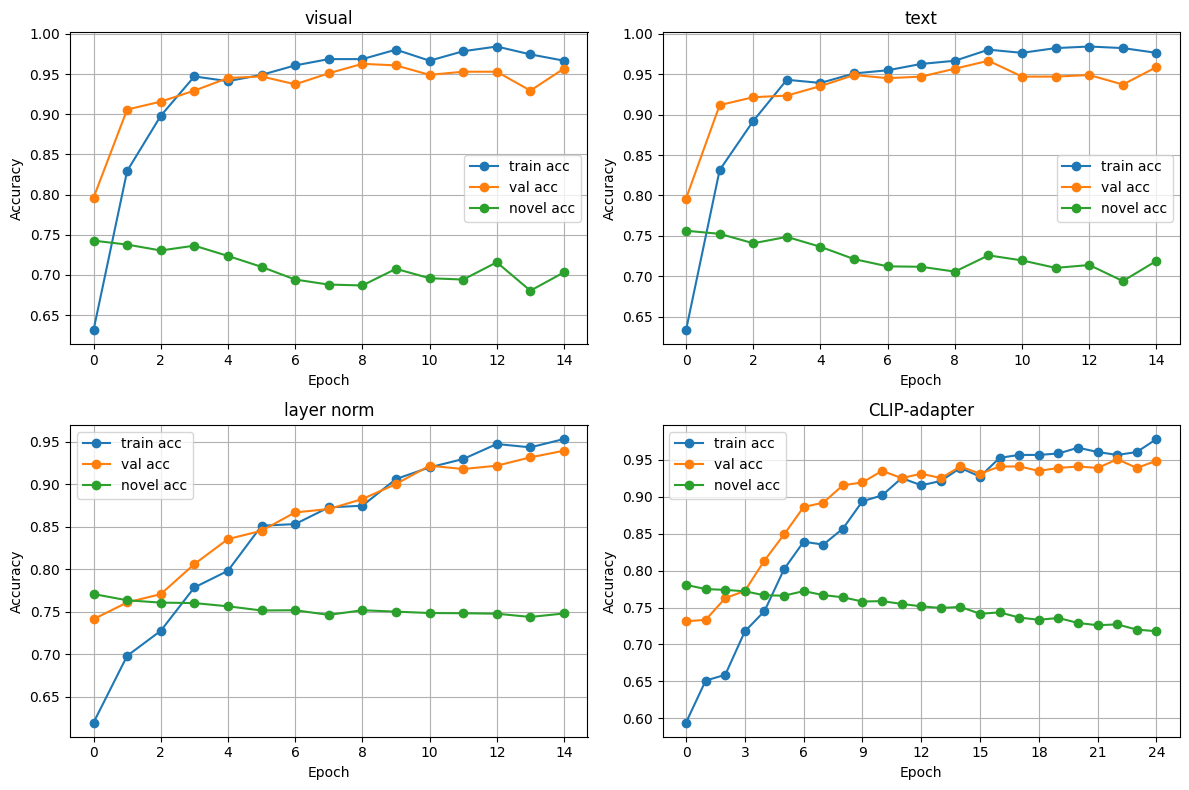

In [ ]:
# show training process for text and adapter fine-tuning

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, parameters_name in enumerate(parameters_names):
    ax = axes[i]
    x = list(range(len(train_history_ft[parameters_name])))

    ax.plot(x, train_history_ft[parameters_name], label=f'train acc', marker='o')
    ax.plot(x, val_history_ft[parameters_name], label=f'val acc', marker='o')
    ax.plot(x, novel_history_ft[parameters_name], label=f'novel acc', marker='o')

    ax.set_title(parameters_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

As we expected, these approaches fail to deliver an acceptable performance on novel classes. This is due to the fact that we are training only on a restricted dataset of base classes, without any kind of control method for the overfitting on them.
In particular, we notice that fine-tuning on projection layers is the approach that yields the worst performance since it specializes too much on base classes.
Instead, layer norm performs in a very stable way also on novel classes, and we can see it as a baseline to beat with our approach.
Also we can see how CLIP-Adapter obtains the highest performance, without compromising too much novel accuracy.
It will be interesting to see if with the introduction of distillation we can keep a similiar performance on base classes, with an increase on novel performance.

# Fine-Tuning with distillation

In this section, we use the same models implemented previously, but we modify the **loss function** by introducing a **distillation term**.

Distillation is typically used to transfer knowledge from a larger model to a smaller one. However, in our case, we use it to *remind* the fine-tuned model to stay close to the original CLIP, preserving its generalization capabilities.
Specifically, the distillation term acts as a **penalty** that discourages the fine-tuned model from deviating too far from the pretrained one. The goal is to prevent performance collapse on novel classes during training.

We explore different ways to define this distillation loss, depending on how we measure the "distance" between the original and fine-tuned models:

- **KL divergence** between the probability distributions induced by the logits of the two models $(l_{\text{fine-tuned}}, l_{\text{frozen}})$. This encourages the fine-tuned model to make predictions close to the original ones:
  $$
  KL(l_{\text{fine-tuned}}, l_{\text{frozen}}) = \sum_k [l_{\text{fine-tuned}}]_k \log \left( \frac{[l_{\text{fine-tuned}}]_k}{[l_{\text{frozen}}]_k} \right)
  $$

- **L1 norm** between the features of the two models. This penalizes coordinate-wise deviations:
  $$
  L_1(\text{ft-feature} - \text{frozen-feature}) = \sum_k \left| [\text{ft-feature}]_k - [\text{frozen-feature}]_k \right|
  $$

- **Cosine similarity** between the features. This encourages alignment between feature directions:
  $$
  CS(\text{ft-feature}, \text{frozen-feature}) = \frac{\text{ft-feature} \cdot \text{frozen-feature}}{\|\text{ft-feature}\| \cdot \|\text{frozen-feature}\|}
  $$

We observed that even a simple penalization term—when combined with appropriate hyperparameter tuning—can yield **outstanding results**. Notably, it prevents the usual performance drop on novel classes, while maintaining competitive accuracy on base classes.

The "best" hyperparameter value for the distillation term depends on the goal:
- If retaining accuracy on **novel classes** is the priority, a **higher** distillation weight is recommended.
- If some decline on novel classes is acceptable in favor of better **base class** performance, a **lower** weight may be preferable.

Among the methods explored, **KL divergence** had the most significant positive impact. Adding other losses (L1, cosine) did not consistently improve results. We speculate that this is because KL divergence allows greater flexibility: it aligns the **predictions** without forcing the **features** to match exactly.
So we will have a loss functions that looks like $$ \mathcal{L} = \mathcal{L}_{\text{CE}}(\text{logits}, \text{labels}) + \lambda_{\text{distill}} \cdot KL(\text{logits}, \text{frozen_logits}) $$
We didn't report all the results with the different possible choices of distillation type for readability.

To further stabilize training, we also implemented a **cosine annealing-style schedule** for the distillation weight. This serves two purposes:
- It allows the model to be more expressive in the later stages of training, boosting base class accuracy.
- It reduces the risk of instability from excessive penalization in the final training steps.

In our experiments, we used an initial KL divergence weight of **1**, as this value provided a good trade-off: the model maintained strong performance on base classes without severely compromising novel class accuracy.

In the following cells, we implement the distillation loss functions and apply them to the training procedure introduced earlier.


In [ ]:
def kl_loss_computation(frozen_text_features, frozen_image_features, logits):

  """
  function for computing the distillation loss using kullback-lieber divergence as measure of dissimilarity
  It takes as input the logits of the model of each sample in the batch, and returns
  the normalized sum of the KL divergences between the input logits and the ones computed by the original CLIP for each batch
  """

  # cosine similarity between image and text features of the frozen model
  frozen_logits = logit_scale.exp() * frozen_image_features @ frozen_text_features.T

  # compute KL Divergence between the logits computed by the current model and the ones computed by the frozen model

  # log on the softmax of the logits computed by our model (per each batch)
  log_probs = F.log_softmax(logits, dim=1)
  # softmax of the logits computed by the frozen model (per each batch)
  target_probs = F.softmax(frozen_logits, dim=1)
  # compute and sum the kl Divergences for all the samples in the batch. Then normalize the result by the batch size
  kl_loss = F.kl_div(log_probs, target_probs, reduction="batchmean")

  return kl_loss

In [ ]:
def l1_loss_computation(image_features, text_features, frozen_image_features, frozen_text_features):
  """
  function for computing the distillation loss using L1 norm between features
  """

  l1_loss_image = F.l1_loss(image_features, frozen_image_features, reduction='mean')
  l1_loss_text = F.l1_loss(text_features, frozen_text_features, reduction='mean')

  l1_loss = l1_loss_image + l1_loss_text

  return l1_loss

In [ ]:
def cs_loss_computation(image_features, text_features, frozen_image_features, frozen_text_features):
  """
  function for computing the distillation loss using cosine similarity between features of the two models
  """

  cs_loss_image = F.cosine_similarity(image_features, frozen_image_features, dim=1).mean()
  cs_loss_text = F.cosine_similarity(text_features, frozen_text_features, dim=1).mean()

  cs_loss = (cs_loss_image + cs_loss_text) / 2

  return cs_loss

In [ ]:
def ft_distil(model, trainable_parameters, train_dataloader, val_dataloader, categories, ce_const, distil_kl, distil_l1, distil_cs, lr, wd, num_epochs, device, novel_computation=False, text_inputs=None, alpha_adapter=False):

  """
  function to fine-tune the model with distillation:
  the stoppage criterium will be based on the validation accuracy
  takes in input:
  - model: clip or clip_adapter
  - trainable_parameters: a list of parameters that we will finetune, that will define the fine-tune strategy that we chose
  - train_dataloader: the dataloader for training
  - val_dataloader : the dataloader for validation
  - categories: list of indexes that correspond to  base classes
  - ce_const : parameter that will multiply the cross-entropy loss term
  - distill_kl : parameter that will multiply the KL distillation loss
  - distill_l1 : parameter that will multiply the L1 distillation loss
  - distill_cs : parameter that will multiply the cosine similarity distillation loss
  - lr : learning rate
  - wd: weight decay
  - num_epochs: total number of epochs that we use
  - device: cuda or cpu
  - novel_computation: parameter for deciding if we should save the performance of the model during training on novel classes for the plots
  - text_inputs: if None we use the usual prompts
  - alpha_adapter : parameter for deciding if we should use a higher learning rate for alpha in CLIP-Adapter
  """
  model = model.float()

  # Freeze all parameters in the model
  for param in model.parameters():
    param.requires_grad = False

  # Unfreeze the trainable parameters
  for param in trainable_parameters:
    param.requires_grad = True

  # Use cross-entropy loss and Adam as optimizer
  criterion = torch.nn.CrossEntropyLoss()

  if alpha_adapter:

    params_with_different_lr = [
    {
        "params": [p for n, p in model.adapter.named_parameters() if "mlp" in n],
        "lr": lr * 2
    },
    {
        "params": [p for n, p in model.adapter.named_parameters() if "mlp" not in n],
        "lr": lr
    }
    ]

    optimizer = torch.optim.Adam(params_with_different_lr, weight_decay=wd)

  else:

    optimizer = Adam(trainable_parameters, lr=lr, weight_decay=wd)

  # Dictionary to assign an index (starting from 0) to each class name (of the base classes)
  contig_cat2idx = {cat: idx for idx, cat in enumerate(categories)}

  # Record the loss values
  saved_accuracy= torch.tensor(0.0)

  # Tokenization of the class names
  if text_inputs == None:
    text_inputs = clip.tokenize(
           [f"a photo of a {CLASS_NAMES[c]}, a type of flower." for c in categories]).to(device)

  # Create an independent copy of CLIP original model (the frozen model) that will be used only for evaluating
  frozen_model = copy.deepcopy(model).eval().to(device)

  # Compute the text representations of the class names with the frozen model of the class names
  with torch.no_grad(): # no gradients are computed for the frozen model evaluation
      frozen_text_features = frozen_model.encode_text(text_inputs).float()
      frozen_text_features_norm = frozen_text_features.norm(dim=-1, keepdim=True)
      frozen_text_features = frozen_text_features/frozen_text_features_norm

  if novel_computation == True:
      novel_acc = []
      train_acc = []
      val_acc = []

  print("🧠 Fine-tuning training+validation on Base Classes")

  for epoch in range(num_epochs):

    # Training

    model.train()
    total_loss = 0
    correct_predictions = 0
    n_images = 0

    for image, target in train_dataloader:

          target = torch.Tensor([contig_cat2idx[t.item()] for t in target]).long()

          image = image.to(device).float()
          target = target.to(device)

          # compute text representation of the targets in the batch
          text_features = model.encode_text(text_inputs).float()
          # normalization
          text_features_norm = text_features.norm(dim=-1, keepdim=True)
          text_features = text_features/text_features_norm

          # compute visual representation of the images in the batch
          image_features = model.encode_image(image).float()
          # normalization
          image_features_norm = image_features.norm(dim=-1, keepdim=True)
          image_features = image_features/image_features_norm

          # cosine similarity between image and text features
          logits = logit_scale.exp() * image_features @ text_features.T

          # Compute the visual representations of the images of the batch with the frozen model
          with torch.no_grad(): # no gradients are computed for the frozen model evaluation
              frozen_image_features = frozen_model.encode_image(image).float()
              frozen_image_features_norm = frozen_image_features.norm(dim=-1, keepdim=True)
              frozen_image_features = frozen_image_features/frozen_image_features_norm


          # compute the whole loss

          loss = torch.tensor(0.0, device=device)

          # compute cross-entropy loss
          if ce_const != 0:
            ce_loss = criterion(logits, target)
            loss += ce_const * ce_loss


          # use a cosine decay for the distillation terms in the loss
          cosine_decay = 0.3 + 0.7 * 0.5 * (1 + math.cos(math.pi * epoch / num_epochs))
          #cosine_decay = 1

          # compute KL Distillation
          if distil_kl != 0:
            kl_loss = kl_loss_computation(frozen_text_features, frozen_image_features, logits)
            loss += cosine_decay * distil_kl * kl_loss

          # compute L1 Distillation
          if distil_l1 != 0:
            l1_loss = l1_loss_computation(image_features, text_features, frozen_image_features, frozen_text_features)
            loss += cosine_decay * distil_l1 * l1_loss

          # compute CS Distillation
          if distil_cs != 0:
            cs_loss = -cs_loss_computation(image_features, text_features, frozen_image_features, frozen_text_features)
            loss += cosine_decay * distil_cs * cs_loss

          # Backpropagation
          loss.backward()
          optimizer.step()
          optimizer.zero_grad()

          # Training accuracy computation
          total_loss += loss.item()
          predicted_class = logits.argmax(dim=-1)
          correct_predictions += (predicted_class == target).sum().item()
          n_images += len(target)

    train_accuracy = correct_predictions / n_images
    print(f"Epoch {epoch + 1}, Training accuracy: {train_accuracy*100:.2f}%")

    # Validation of one epoch

    model.eval()
    total_loss = 0
    correct_predictions = 0
    n_images = 0

    with torch.no_grad():
      for image, target in val_dataloader:

          target = torch.Tensor([contig_cat2idx[t.item()] for t in target]).long()

          image = image.to(device).float()
          target = target.to(device)

          text_features = model.encode_text(text_inputs).float()
          # and here we normalize them (standard pratice with CLIP)
          text_feature_norm = text_features.norm(dim=-1, keepdim=True)
          text_features = text_features/text_feature_norm # per avere norma 1 per calcolare cosine similarity

          # forward image through CLIP image encoder
          image_features = model.encode_image(image).float()
          # and normalize
          image_features_norm = image_features.norm(dim=-1, keepdim=True)
          image_features = image_features / image_features_norm # per avere norma 1 per calcolare cosine similarity

          # here cosine similarity between image and text features and keep the argmax for every row (every image)
          logits = logit_scale.exp() * image_features @ text_features.T

          # compute the whole loss
          loss = torch.tensor(0.0, device=device)

          # compute cross-entropy loss
          if ce_const != 0:
            ce_loss = criterion(logits, target)
            loss += ce_const * ce_loss


          # Validation accuracy computation
          total_loss += loss.item()
          predicted_class = logits.argmax(dim=-1)
          correct_predictions += (predicted_class == target).sum().item()
          n_images += len(target)

      validation_accuracy = correct_predictions / n_images
      print(f"Epoch {epoch + 1}, Validation accuracy: {validation_accuracy*100:.2f}%")

      if novel_computation == True:
        novel_accuracy, _, _ = eval(model=model, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
        train_acc.append(train_accuracy)
        val_acc.append(validation_accuracy)
        novel_acc.append(novel_accuracy)

    if validation_accuracy > saved_accuracy:
      saved_accuracy = validation_accuracy
      saved_model = copy.deepcopy(model.state_dict())
      n_net = epoch

  print(f"selected net at epoch {n_net+1}")
  model.load_state_dict(saved_model)

  if novel_computation == True:
      return model, train_acc, val_acc, novel_acc
  else:
      return model

In the following cells we fine-tune the models with distillation and cross-entropy, for then saving the results.
In particular the distillation parameter has been chosen as the "best" ( best compromise between performance on base and novels) that we found for each of the different approaches.

In [ ]:
base_accuracies_distil = {}
novel_accuracies_distil = {}
harmonic_means_distil = {}
cm_base_distil = {}
cm_novel_distil = {}

train_history_distil = {}
val_history_distil = {}
novel_history_distil = {}

In [ ]:
# visual fine-tuning

train_dataloader = get_dataloader(augmented_train_base, batch_size=batch_size, shuffle=True, num_workers=2, seed=seed)
val_dataloader = get_dataloader(val_base, batch_size=batch_size, shuffle=False, num_workers=2, seed=seed)

parameters_name = "visual"

model, _ = clip.load("ViT-B/16", device=device)

trainable_parameters = get_trainable_parameters(model, parameters_name)
model_ft, train_history_distil[parameters_name], val_history_distil[parameters_name], novel_history_distil[parameters_name] = ft_distil(
                model = model,
                trainable_parameters = trainable_parameters,
                train_dataloader = train_dataloader,
                val_dataloader = val_dataloader,
                categories = base_classes,
                ce_const = 1,
                distil_kl = 1,
                distil_l1 = 0,
                distil_cs = 0,
                lr = 0.0001,
                wd = 0.0001,
                num_epochs = 20,
                novel_computation = True,
                device = device,
                )

base_accuracies_distil[parameters_name], _, cm_base_distil[parameters_name] = eval(model=model_ft, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracies_distil[parameters_name], _, cm_novel_distil[parameters_name]= eval(model=model_ft, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
harmonic_means_distil[parameters_name] = harmonic_mean(base_accuracies_distil[parameters_name], novel_accuracies_distil[parameters_name])

print(f"🔍 Base classes accuracy: {base_accuracies_distil[parameters_name]*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracies_distil[parameters_name]*100:.2f}%")
print(f"🔍 Harmonic Mean: {harmonic_means_distil[parameters_name] *100:.2f}%")

🧠 Fine-tuning training+validation on Base Classes
Epoch 1, Training accuracy: 63.33%
Epoch 1, Validation accuracy: 80.98%
Epoch 2, Training accuracy: 78.04%
Epoch 2, Validation accuracy: 87.25%
Epoch 3, Training accuracy: 83.14%
Epoch 3, Validation accuracy: 88.24%
Epoch 4, Training accuracy: 86.08%
Epoch 4, Validation accuracy: 85.88%
Epoch 5, Training accuracy: 87.45%
Epoch 5, Validation accuracy: 87.84%
Epoch 6, Training accuracy: 88.63%
Epoch 6, Validation accuracy: 87.65%
Epoch 7, Training accuracy: 88.82%
Epoch 7, Validation accuracy: 90.59%
Epoch 8, Training accuracy: 90.00%
Epoch 8, Validation accuracy: 88.82%
Epoch 9, Training accuracy: 90.20%
Epoch 9, Validation accuracy: 91.18%
Epoch 10, Training accuracy: 92.94%
Epoch 10, Validation accuracy: 90.00%
Epoch 11, Training accuracy: 90.98%
Epoch 11, Validation accuracy: 91.57%
Epoch 12, Training accuracy: 95.49%
Epoch 12, Validation accuracy: 91.37%
Epoch 13, Training accuracy: 94.90%
Epoch 13, Validation accuracy: 93.33%
Epoch 

In [ ]:
# Text fine-tuning

train_dataloader = get_dataloader(augmented_train_base, batch_size=batch_size, shuffle=True, num_workers=2, seed=seed)
val_dataloader = get_dataloader(val_base, batch_size=batch_size, shuffle=False, num_workers=2, seed=seed)

parameters_name = "text"

model, _ = clip.load("ViT-B/16", device=device)

trainable_parameters = get_trainable_parameters(model, parameters_name)
model_ft, train_history_distil[parameters_name], val_history_distil[parameters_name], novel_history_distil[parameters_name] = ft_distil(
                model = model,
                trainable_parameters = trainable_parameters,
                train_dataloader = train_dataloader,
                val_dataloader = val_dataloader,
                categories = base_classes,
                ce_const = 1,
                distil_kl = 0.5,
                distil_l1 = 0,
                distil_cs = 0,
                lr = 0.0001,
                wd = 0.0001,
                num_epochs = 20,
                novel_computation = True,
                device = device,
                )

base_accuracies_distil[parameters_name], _, cm_base_distil[parameters_name] = eval(model=model_ft, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracies_distil[parameters_name], _, cm_novel_distil[parameters_name]= eval(model=model_ft, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
harmonic_means_distil[parameters_name] = harmonic_mean(base_accuracies_distil[parameters_name], novel_accuracies_distil[parameters_name])

print(f"🔍 Base classes accuracy: {base_accuracies_distil[parameters_name]*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracies_distil[parameters_name]*100:.2f}%")
print(f"🔍 Harmonic Mean: {harmonic_means_distil[parameters_name] *100:.2f}%")

🧠 Fine-tuning training+validation on Base Classes
Epoch 1, Training accuracy: 62.55%
Epoch 1, Validation accuracy: 81.96%
Epoch 2, Training accuracy: 81.18%
Epoch 2, Validation accuracy: 90.00%
Epoch 3, Training accuracy: 85.88%
Epoch 3, Validation accuracy: 91.37%
Epoch 4, Training accuracy: 91.37%
Epoch 4, Validation accuracy: 90.00%
Epoch 5, Training accuracy: 92.16%
Epoch 5, Validation accuracy: 92.16%
Epoch 6, Training accuracy: 92.75%
Epoch 6, Validation accuracy: 91.96%
Epoch 7, Training accuracy: 92.94%
Epoch 7, Validation accuracy: 92.94%
Epoch 8, Training accuracy: 93.33%
Epoch 8, Validation accuracy: 92.35%
Epoch 9, Training accuracy: 93.33%
Epoch 9, Validation accuracy: 92.75%
Epoch 10, Training accuracy: 96.47%
Epoch 10, Validation accuracy: 92.55%
Epoch 11, Training accuracy: 95.69%
Epoch 11, Validation accuracy: 94.31%
Epoch 12, Training accuracy: 97.65%
Epoch 12, Validation accuracy: 93.14%
Epoch 13, Training accuracy: 96.86%
Epoch 13, Validation accuracy: 93.53%
Epoch 

In [ ]:
# Layer Norm fine-tuning

train_dataloader = get_dataloader(augmented_train_base, batch_size=batch_size, shuffle=True, num_workers=2, seed=seed)
val_dataloader = get_dataloader(val_base, batch_size=batch_size, shuffle=False, num_workers=2, seed=seed)

parameters_name = "layer norm"

model, _ = clip.load("ViT-B/16", device=device)

trainable_parameters = get_trainable_parameters(model, parameters_name)
model_ft, train_history_distil[parameters_name], val_history_distil[parameters_name], novel_history_distil[parameters_name] = ft_distil(
                model = model,
                trainable_parameters = trainable_parameters,
                train_dataloader = train_dataloader,
                val_dataloader = val_dataloader,
                categories = base_classes,
                ce_const = 1,
                distil_kl = 0.5,
                distil_l1 = 0,
                distil_cs = 0,
                lr = 0.0005,
                wd = 0.0001,
                num_epochs = 30,
                novel_computation = True,
                device = device,
                )

base_accuracies_distil[parameters_name], _, cm_base_distil[parameters_name] = eval(model=model_ft, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracies_distil[parameters_name], _, cm_novel_distil[parameters_name]= eval(model=model_ft, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
harmonic_means_distil[parameters_name] = harmonic_mean(base_accuracies_distil[parameters_name], novel_accuracies_distil[parameters_name])

print(f"🔍 Base classes accuracy: {base_accuracies_distil[parameters_name]*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracies_distil[parameters_name]*100:.2f}%")
print(f"🔍 Harmonic Mean: {harmonic_means_distil[parameters_name] *100:.2f}%")

🧠 Fine-tuning training+validation on Base Classes
Epoch 1, Training accuracy: 61.96%
Epoch 1, Validation accuracy: 75.10%
Epoch 2, Training accuracy: 69.61%
Epoch 2, Validation accuracy: 76.08%
Epoch 3, Training accuracy: 70.59%
Epoch 3, Validation accuracy: 76.86%
Epoch 4, Training accuracy: 73.73%
Epoch 4, Validation accuracy: 79.61%
Epoch 5, Training accuracy: 76.86%
Epoch 5, Validation accuracy: 81.96%
Epoch 6, Training accuracy: 80.39%
Epoch 6, Validation accuracy: 82.16%
Epoch 7, Training accuracy: 81.96%
Epoch 7, Validation accuracy: 84.51%
Epoch 8, Training accuracy: 83.14%
Epoch 8, Validation accuracy: 84.90%
Epoch 9, Training accuracy: 84.71%
Epoch 9, Validation accuracy: 85.88%
Epoch 10, Training accuracy: 87.25%
Epoch 10, Validation accuracy: 86.86%
Epoch 11, Training accuracy: 87.84%
Epoch 11, Validation accuracy: 87.25%
Epoch 12, Training accuracy: 86.67%
Epoch 12, Validation accuracy: 87.45%
Epoch 13, Training accuracy: 88.82%
Epoch 13, Validation accuracy: 88.63%
Epoch 

In [ ]:
# Adapter fine-tuning

train_dataloader = get_dataloader(augmented_train_base, batch_size=batch_size, shuffle=True, num_workers=2, seed=seed)
val_dataloader = get_dataloader(val_base, batch_size=batch_size, shuffle=False, num_workers=2, seed=seed)

clip_model, _ = clip.load("ViT-B/16", device=device)
clip_model = clip_model.float()
model = CLIPWithAdapter(clip_model, mode=0) #
model = model.to(device)
trainable_parameters = list(model.adapter.parameters())

parameters_name = "CLIP-adapter"

model_ft, train_history_distil[parameters_name], val_history_distil[parameters_name], novel_history_distil[parameters_name] = ft_distil(
                model = model,
                trainable_parameters = trainable_parameters,
                train_dataloader = train_dataloader,
                val_dataloader = val_dataloader,
                categories = base_classes,
                ce_const = 1,
                distil_kl = 1,
                distil_l1 = 0,
                distil_cs = 0,
                lr = 0.0005,
                wd = 0.0001,
                num_epochs = 40,
                novel_computation = True,
                alpha_adapter = False,
                device = device,
                )

base_accuracies_distil[parameters_name], _, cm_base_distil[parameters_name] = eval(model=model_ft, dataset=test_base, categories=base_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Base Classes")
novel_accuracies_distil[parameters_name], _, cm_novel_distil[parameters_name]= eval(model=model_ft, dataset=test_novel, categories=novel_classes, batch_size=128, device=device, label="🧠 Zero-shot evaluation on Novel Classes")
harmonic_means_distil[parameters_name] = harmonic_mean(base_accuracies_distil[parameters_name], novel_accuracies_distil[parameters_name])

print(f"🔍 Base classes accuracy: {base_accuracies_distil[parameters_name]*100:.2f}%")
print(f"🔍 Novel classes accuracy: {novel_accuracies_distil[parameters_name]*100:.2f}%")
print(f"🔍 Harmonic Mean: {harmonic_means_distil[parameters_name] *100:.2f}%")

🧠 Fine-tuning training+validation on Base Classes
Epoch 1, Training accuracy: 60.59%
Epoch 1, Validation accuracy: 73.73%
Epoch 2, Training accuracy: 65.69%
Epoch 2, Validation accuracy: 74.31%
Epoch 3, Training accuracy: 65.88%
Epoch 3, Validation accuracy: 76.86%
Epoch 4, Training accuracy: 67.65%
Epoch 4, Validation accuracy: 77.65%
Epoch 5, Training accuracy: 71.57%
Epoch 5, Validation accuracy: 81.18%
Epoch 6, Training accuracy: 73.73%
Epoch 6, Validation accuracy: 81.96%
Epoch 7, Training accuracy: 77.45%
Epoch 7, Validation accuracy: 84.90%
Epoch 8, Training accuracy: 77.84%
Epoch 8, Validation accuracy: 85.49%
Epoch 9, Training accuracy: 79.22%
Epoch 9, Validation accuracy: 85.10%
Epoch 10, Training accuracy: 82.55%
Epoch 10, Validation accuracy: 87.65%
Epoch 11, Training accuracy: 82.16%
Epoch 11, Validation accuracy: 86.47%
Epoch 12, Training accuracy: 86.08%
Epoch 12, Validation accuracy: 87.45%
Epoch 13, Training accuracy: 82.75%
Epoch 13, Validation accuracy: 88.04%
Epoch 

We save the results of our finetuning with distillation, to be able to report the graphics and confusion matrices

In [ ]:
# save computed data

torch.save(base_accuracies_distil, "base_accuracies_distil.pt")
torch.save(novel_accuracies_distil, "novel_accuracies_distil.pt")
torch.save(harmonic_means_distil, "harmonic_means_distil.pt")
torch.save(cm_base_distil, "cm_base_distil.pt")
torch.save(cm_novel_distil, "cm_novel_distil.pt")
torch.save(train_history_distil, "train_history_distil.pt")
torch.save(val_history_distil, "val_history_distil.pt")
torch.save(novel_history_distil, "novel_history_distil.pt")

We report the novel, base accuracies and harmonic means of the different fine-tunings of the model, together with confusion matrices and training evolution of performance on validation set for base and on test set for novel.

In [ ]:
# Print the metrics for each fine-tuning

rows = []
for param in parameters_names:
    row = {
        "Base Accuracy": base_accuracies_distil[param],
        "Novel Accuracy": novel_accuracies_distil[param],
        "Harmonic Mean": harmonic_means_distil[param]
    }
    rows.append(row)

df = pd.DataFrame(rows, index=parameters_names)
df = df.apply(lambda col: col.map(lambda x: f"{x * 100:.2f}%"))

print(df)

             Base Accuracy Novel Accuracy Harmonic Mean
visual              92.64%         76.14%        83.59%
text                94.10%         74.59%        83.22%
layer norm          94.34%         76.09%        84.24%
CLIP-adapter        93.41%         77.61%        84.78%


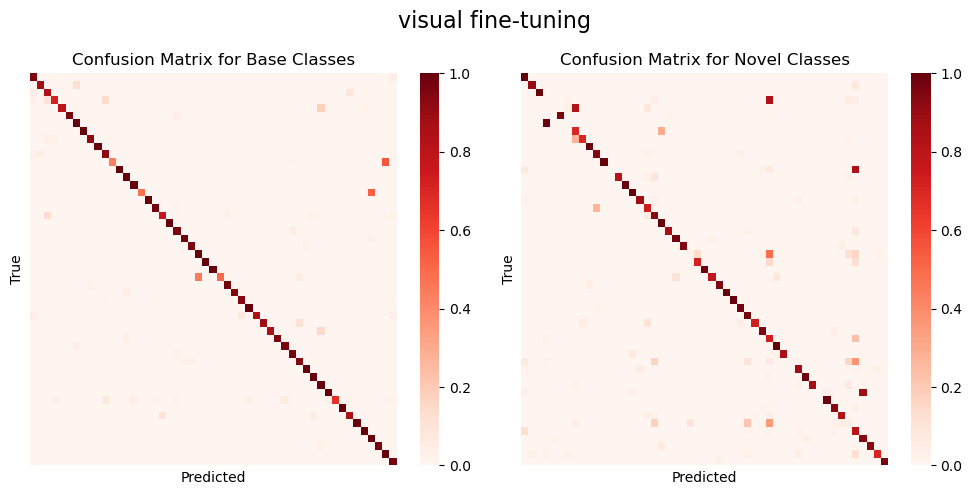

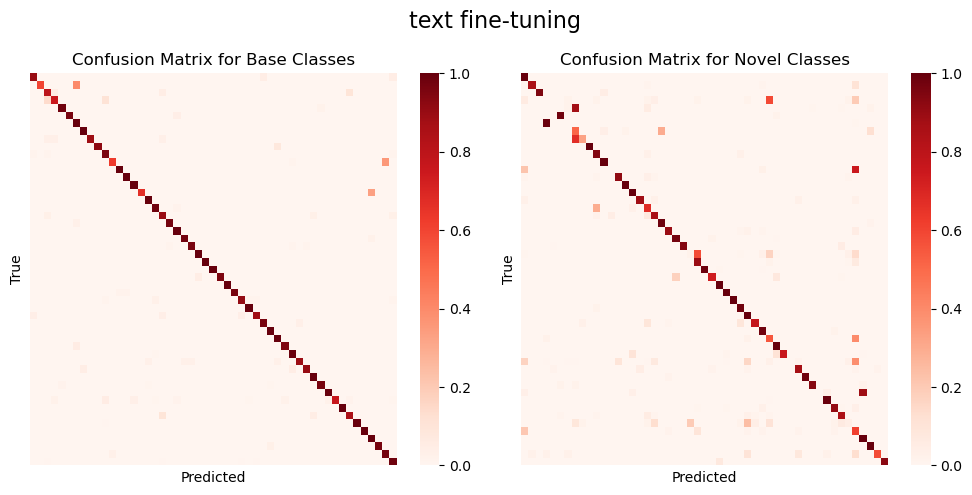

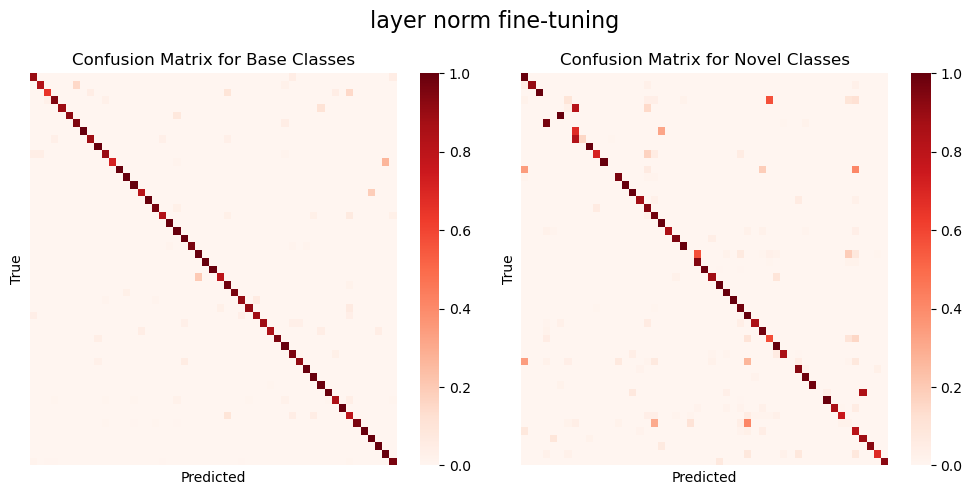

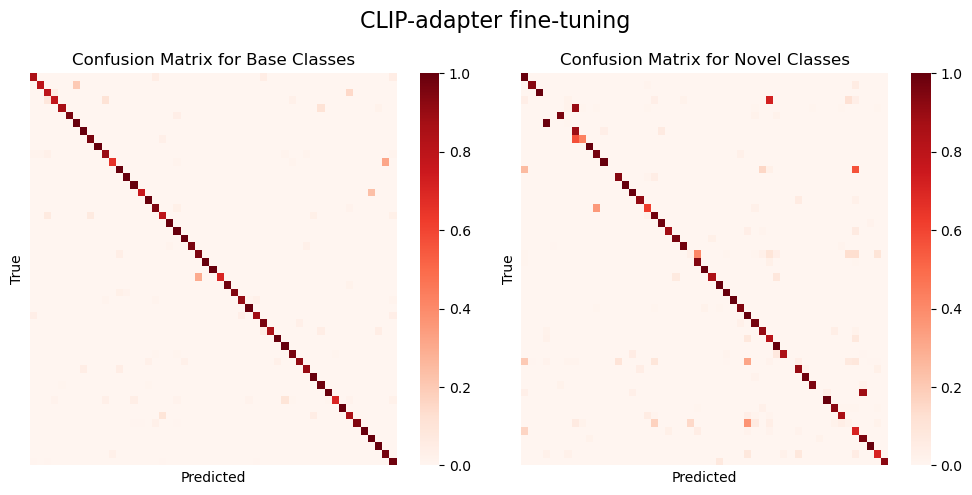

In [ ]:
# show confusion matrices on both base and novel test sets

for param_name in parameters_names:

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    plot_confusion_matrix(cm_base_distil[param_name], ax=axes[0], dataset="Base Classes")
    plot_confusion_matrix(cm_novel_distil[param_name], ax=axes[1], dataset="Novel Classes")

    fig.suptitle(f"{param_name} fine-tuning", fontsize=16)

    plt.tight_layout()
    plt.show()

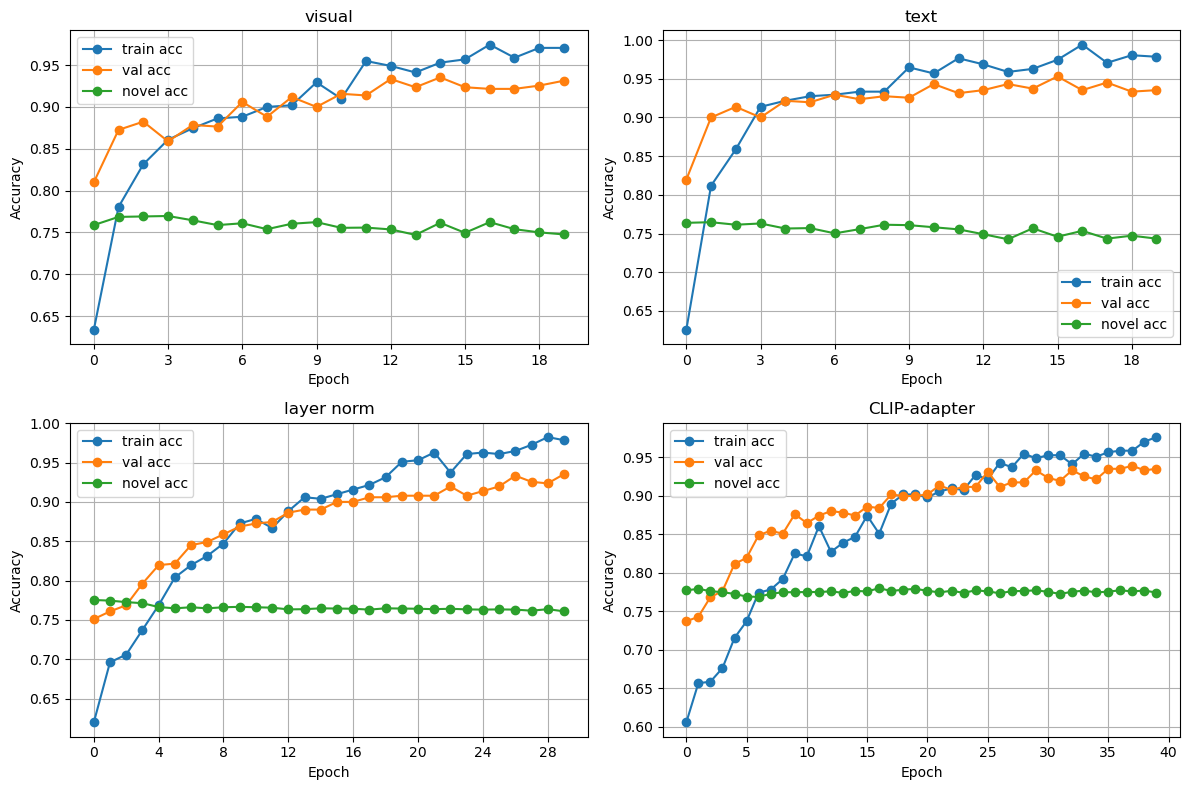

In [ ]:
# show training process for text and adapter fine-tuning

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 righe, 2 colonne
axes = axes.flatten()  # Rende l'array 1D per iterare facilmente

for i, parameters_name in enumerate(parameters_names):
    ax = axes[i]
    x = list(range(len(train_history_distil[parameters_name])))

    ax.plot(x, train_history_distil[parameters_name], label=f'train acc', marker='o')
    ax.plot(x, val_history_distil[parameters_name], label=f'val acc', marker='o')
    ax.plot(x, novel_history_distil[parameters_name], label=f'novel acc', marker='o')

    ax.set_title(parameters_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # <-- forza tick interi
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

How can we observe from the obtained results, Novel accuracy decreases slower during training than without distillation, while having a steady improvement of base accuracy.

In particular the results that are noteworthy are especially the ones obtained on layer norm and CLIP-Adapter:
- in layer norm distillation not only keeps the fine-tuning from decreasing novel performance but it also stabilizes training making it achieve even higher results on base classes. This can be due the fact that distil acts like a regularizer and so can in fact make training smoother.
- in CLIP-Adapter we obtain oustanding results on novel classes whose performance is barely decreased wrt the zero-shot performance of CLIP. We can speculate that this phenomenon can be also attributed to the fact that since the adapter is trained from scratch, the guidance of the "teacher"( original CLIP ) can be beneficial.
- in general, for each one of the approaches, we obtain a better result ( as we expected) on novel classes, but at the cost of a slight decrease on base classes accuracy.

If we would be more interested in preserving the novel accuracy we could choose an higher distillation parameter (like 2 for example), sacrificing a bit of base performance.

#### Fine-tuning with distillation

| Method        | Base Accuracy | Novel Accuracy | Harmonic Mean |
|--------------|----------------|----------------|----------------|
| visual       | 92.64%         | 76.14%         | 83.59%         |
| text         | 94.10%         | 74.59%         | 83.22%         |
| layer norm   | 94.34%         | 76.09%         | 84.24%         |
| CLIP-adapter | 93.41%         | 77.61%         | 84.78%         |

#### Fine-tuning without distillation

| Method        | Base Accuracy | Novel Accuracy | Harmonic Mean |
|--------------|----------------|----------------|----------------|
| visual       | 93.53%         | 68.69%         | 79.21%         |
| text         | 95.35%         | 72.58%         | 82.42%         |
| layer norm   | 92.40%         | 74.78%         | 82.66%         |
| CLIP-adapter | 94.34%         | 72.71%         | 82.13%         |

# Ensemble

In this section,  we try to have even more control on the performance on novel classes by introducing an ensemble.

This particular ensemble doesn't leverage a technique like bagging, but instead every model in the ensemble will be fine-tuned in a different way as now we will describe.

The idea that we had was to retain  part of base classes for a novel surrogate that we could use for controlling better the performance on unseen classes.
Specifically the  chosen classes will  be used for training, but only for distillation purposes,  not for the usual cross entropy loss.

In practice we take a random split of base classes, obtaining 2 datasets:
- standard_train that will contain all the data coming from the classes that we choose for the usual training (cross-entropy + distillation)
- control_train that will contain the data from the remaining classes, that will be used only for computing the distillation

We added also an intermediate step.
Since in general we use distillation for not "forgetting" the strong zero-shot capability of CLIP, a clever choice could be selecting for the "novel surrogates", only the classes that are classified with an high accuracy by CLIP.
This choice is reasonable because:
- we penalize the "distance" between the finetuned model and the original, because we know that the original is good in that classes
- we don't lose too much by retaining the chosen classes from performing "cross entropy training" since in general the images of those classes are already classified correctly by the original model

In particular, during each step of the epoch, we'll sample a batch ($B_{std}$) from the standard_train set, and at the same time, we sample another batch ($B_{control}$) from the control_train set.
- for the $B_{std}$, we compute both cross-entropy and KL divergence relative only to the standard classes.
- for the $B_{control}$, we compute only KL divergence relative to all base classes.

Thus, the loss to optimize is:
$$ \mathcal{L(B_{std},B_{control})} = \lambda_{\text{CE}} \cdot \mathcal{L}_{\text{CE}}(B_{std}) + \lambda_{\text{distil_std}} \cdot \mathcal{L}_{\text{KL}}(B_{std}) + \lambda_{\text{distil_control}} \cdot \mathcal{L}_{\text{KL}}(B_{control})$$

After we trained these different models, we use their prediction weighted on their confidence for a majority vote between models.
In particular for selecting the "good classes" (the ones that can be chosen for being in the only distillation split), we use a threshold of $0.8$ on the accuracy of the data in the class.
  

In [ ]:
model, _ = clip.load("ViT-B/16", device=device)

model.eval()

# Report the accuracy of original CLIP on each class
with torch.no_grad():
    _, base_acc_list, _ = eval(model=model, dataset=val_base, categories=base_classes, batch_size=batch_size, device=device)

# Select the classes with accuracy larger than a fixed threshold
good_threshold = 0.8
good_base_classes = [i for i in range(len(base_acc_list)) if base_acc_list[i]>=good_threshold]
print("")
print(f"there are {len(good_base_classes)} good classes")


there are 33 good classes


In the following cell we actually compute the splits. We obtain as a result the two list of indexes standard_classes, control_classes, and the augmented training datasets standard_train and control_train.

In [ ]:
# Fix the number of splits for the ensamble, and the number of control classes to use
n_splits = 15
num_control_classes = 11

base_classes_copy = base_classes[:]
good_base_classes_copy = good_base_classes[:]

# Produce the splits of the good classes
splits = []
for i in range(n_splits):

    random.seed(seed + i)  # we change the split for having a different and deterministic split every time
    random.shuffle(good_base_classes_copy)

    control_classes = good_base_classes_copy[:num_control_classes]
    standard_classes = [x for x in base_classes_copy if x not in control_classes]

    splits.append((standard_classes, control_classes))

# Split the training and validation datasets according to such splits
train_list = []
for standard_classes, control_classes in splits:

    # standard train dataset for the current split
    standard_train, _ = split_data(train_set, standard_classes)
    standard_train = AugmentedDataset(data=standard_train, transform=augmentation_transforms)

    # control train dataset for the current split
    control_train, _ = split_data(train_set, control_classes)

    train_list.append((standard_train, control_train, standard_classes, control_classes))

In the following cell we implement the code to produce balanced control-batches (with exactly one data per class). This is done to have a more stable regularization through the control term during the training.

In [ ]:
class BalancedBatchSampler(Sampler):
    def __init__(self, labels, batch_size, seed=0):
        assert batch_size == len(set(labels)), "Batch size must be equal to the number of classes"
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.seed = seed

        # Mappa da classe a lista di indici
        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(self.labels):
            self.class_to_indices[label].append(idx)

        self.class_labels = list(self.class_to_indices.keys())
        self.num_batches = min(len(indices) for indices in self.class_to_indices.values())

    def __iter__(self):
        rng = random.Random(self.seed)

        # Shuffle per classe
        for label in self.class_labels:
            rng.shuffle(self.class_to_indices[label])

        for i in range(self.num_batches):
            batch = [self.class_to_indices[label][i] for label in self.class_labels]
            rng.shuffle(batch)
            yield batch

    def __len__(self):
        return self.num_batches

def get_balanced_dataloader(dataset, batch_size, shuffle, num_workers, seed):
    """
    Returns a dataloader with balanced batches.
    """
    labels = [sample[1] for sample in dataset]

    sampler = BalancedBatchSampler(labels, batch_size=batch_size, seed=seed)

    def worker_init_fn(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
        torch.manual_seed(worker_seed)

    return torch.utils.data.DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=num_workers,
        worker_init_fn=worker_init_fn
    )

In [ ]:
def ft_ensemble(model, trainable_parameters, standard_train_dataloader, control_train_dataloader, val_dataloader, standard_categories, all_categories, ce_const, distil_standard, distil_control, lr, wd, num_epochs, device, alpha_adapter=False):
  """
  function to fine-tune the model with distillation:
  the stoppage criterium will be based on the validation accuracy
  takes in input:
  - model: clip or clip_adapter
  - trainable_parameters: a list of parameters that we will finetune, that will define the fine-tune strategy that we chose
  - train_dataloader: the dataloader for training
  - val_dataloader : the dataloader for validation
  - standard_categories : list of indexes corresponding to standard base classes
  - all_categories: list of indexes that correspond to  all base classes
  - ce_const : parameter that will multiply the cross-entropy loss term
  - distill_standard : parameter that will multiply the standard distillation loss
  - distill_control : parameter that will multiply the  distillation loss on the "control classes"
  - lr : learning rate
  - wd: weight decay
  - num_epochs: total number of epochs that we use
  - device: cuda or cpu
  - novel_computation: parameter for deciding if we should save the performance of the model during training on novel classes for the plots
  - text_inputs: if None we use the usual prompts
  - alpha_adapter : parameter for deciding if we should use a higher learning rate for alpha in CLIP-Adapter
  """

  model = model.float()

  # Freeze all parameters in the model
  for param in model.parameters():
      param.requires_grad = False

  # Unfreeze the trainable parameters
  for param in trainable_parameters:
    param.requires_grad = True

  # Use cross-entropy loss and Adam as optimizer
  criterion = torch.nn.CrossEntropyLoss()

  if alpha_adapter:

    params_with_different_lr = [
    {
        "params": [p for n, p in model.adapter.named_parameters() if "mlp" in n],
        "lr": lr * 2
    },
    {
        "params": [p for n, p in model.adapter.named_parameters() if "mlp" not in n],
        "lr": lr
    }
    ]

    optimizer = torch.optim.Adam(params_with_different_lr, weight_decay=wd)

  else:

    optimizer = Adam(trainable_parameters, lr=lr, weight_decay=wd)

  # Dictionary to assign an index (starting from 0) to the names of the standard classes
  contig_cat2idx = {cat: idx for idx, cat in enumerate(standard_categories)}

  # Dictionary to assign an index (starting from 0) to the names of all base classes
  contig_cat2idx_eval = {cat: idx for idx, cat in enumerate(all_categories)}

  # Record the loss values
  saved_accuracy = torch.tensor(0.0)

  # Tokenization of the class names for standard classes
  standard_text_inputs = clip.tokenize(
           [f"a photo of a {CLASS_NAMES[c]}, a type of flower." for c in standard_categories]).to(device)

  # Tokenization of the class names for all base classes
  all_text_inputs = clip.tokenize(
                       [f"a photo of a {CLASS_NAMES[c]}, a type of flower." for c in all_categories]).to(device)

  # Create an independent copy of CLIP original model (the frozen model) that will be used only for evaluating
  frozen_model = copy.deepcopy(model).eval().to(device)

  # Compute the text representations of the standard class names with the frozen model
  with torch.no_grad():
      frozen_text_features_standard = frozen_model.encode_text(standard_text_inputs).float()
      frozen_text_features_norm_standard = frozen_text_features_standard.norm(dim=-1, keepdim=True)
      frozen_text_features_standard = frozen_text_features_standard/frozen_text_features_norm_standard

  # Compute the text representations of the base class names with the frozen model
  with torch.no_grad():
      frozen_text_features_all = frozen_model.encode_text(all_text_inputs).float()
      frozen_text_features_norm_all = frozen_text_features_all.norm(dim=-1, keepdim=True)
      frozen_text_features_all = frozen_text_features_all/frozen_text_features_norm_all

  print("🧠 Fine-tuning training+validation on Base Classes")

  for epoch in range(num_epochs):

    # Training

    model.train()
    total_loss = 0
    correct_predictions_standard = 0
    n_images_standard = 0
    correct_predictions_control = 0
    n_images_control = 0

    for image_standard, target_standard in standard_train_dataloader:

          # for the selected standard batch:

          image_standard = image_standard.to(device).float()
          target_standard = torch.Tensor([contig_cat2idx[t.item()] for t in target_standard]).long()
          target_standard = target_standard.to(device)

          # compute text representation of the targets in the batch
          text_features_standard = model.encode_text(standard_text_inputs).float()
          # normalization
          text_features_norm_standard = text_features_standard.norm(dim=-1, keepdim=True)
          text_features_standard = text_features_standard/text_features_norm_standard

          # compute visual representation of the images in the batch
          image_features_standard = model.encode_image(image_standard).float()
          # normalization
          image_features_norm_standard = image_features_standard.norm(dim=-1, keepdim=True)
          image_features_standard = image_features_standard/image_features_norm_standard

          # cosine similarity between image and text features
          logits_standard = logit_scale.exp() * image_features_standard @ text_features_standard.T

          # Compute the visual representations of the images of the batch with the frozen model
          with torch.no_grad():
              frozen_image_features_standard = frozen_model.encode_image(image_standard).float()
              frozen_image_features_norm_standard = frozen_image_features_standard.norm(dim=-1, keepdim=True)
              frozen_image_features_standard = frozen_image_features_standard/frozen_image_features_norm_standard

          # select one control batch, and do the same:

          for image_control, target_control in control_train_dataloader:

              image_control = image_control.to(device).float()
              target_control = torch.Tensor([contig_cat2idx_eval[t.item()] for t in target_control]).long()
              # note that target_control is a subset of all the base classes, since
              target_control = target_control.to(device)

              text_features_control = model.encode_text(all_text_inputs).float()
              text_features_norm_control = text_features_control.norm(dim=-1, keepdim=True)
              text_features_control = text_features_control/text_features_norm_control

              image_features_control = model.encode_image(image_control).float()
              image_features_norm_control = image_features_control.norm(dim=-1, keepdim=True)
              image_features_control = image_features_control / image_features_norm_control

              logits_control = logit_scale.exp() * image_features_control @ text_features_control.T

              with torch.no_grad():
                  frozen_image_features_control = frozen_model.encode_image(image_control).float()
                  frozen_image_features_control = frozen_image_features_control / frozen_image_features_control.norm(dim=-1, keepdim=True)

              break

          # compute the whole loss

          loss = torch.tensor(0.0, device=device)

          # compute cross-entropy loss
          if ce_const != 0:
            ce_loss = criterion(logits_standard, target_standard)
            loss += ce_const * ce_loss

          # use a cosine decay for the distillation terms in the loss
          cosine_decay = 0.3 + 0.7 * 0.5 * (1 + math.cos(math.pi * epoch / num_epochs))

          # compute KL Distillation for the standard batch
          if distil_standard != 0:
            kl_loss_standard = kl_loss_computation(frozen_text_features_standard, frozen_image_features_standard, logits_standard)
            loss += cosine_decay * distil_standard * kl_loss_standard

          # compute KL Distillation for the control batch
          if distil_control != 0:
            kl_loss_control = kl_loss_computation(frozen_text_features_all, frozen_image_features_control, logits_control)
            loss += cosine_decay * distil_control * kl_loss_control

          # Backpropagation
          loss.backward()
          optimizer.step()
          optimizer.zero_grad()

          #lr_scheduler.step()

          # Training accuracy computation on standard batch
          total_loss += loss.item()
          predicted_class_standard = logits_standard.argmax(dim=-1)
          correct_predictions_standard += (predicted_class_standard == target_standard).sum().item()
          n_images_standard += len(target_standard)

          # Training accuracy computation on control batch
          predicted_class_control = logits_control.argmax(dim=-1)
          correct_predictions_control += (predicted_class_control == target_control).sum().item()
          n_images_control += len(target_control)

    print(f"Epoch {epoch + 1}, Training accuracy on standard classes: {correct_predictions_standard / n_images_standard*100:.2f}%")
    print(f"Epoch {epoch + 1}, Training accuracy on control classes: {correct_predictions_control / n_images_control*100:.2f}%")

    # Validation of one epoch

    model.eval()
    total_loss = 0
    correct_predictions = 0
    n_images = 0

    with torch.no_grad():

        for image, target in val_dataloader:

          target = torch.Tensor([contig_cat2idx_eval[t.item()] for t in target]).long()

          image = image.to(device).float()
          target = target.to(device)

          text_features = model.encode_text(all_text_inputs).float()
          text_feature_norm = text_features.norm(dim=-1, keepdim=True)
          text_features = text_features/text_feature_norm

          image_features = model.encode_image(image).float()
          image_features_norm = image_features.norm(dim=-1, keepdim=True)
          image_features = image_features / image_features_norm

          logits = logit_scale.exp() * image_features @ text_features.T

          loss = criterion(logits, target)
          total_loss += loss.item()

          # Validation accuracy computation
          predicted_class = logits.argmax(dim=-1)
          correct_predictions += (predicted_class == target).sum().item()
          n_images += len(target)

          val_accuracy = correct_predictions/n_images

        print(f"Epoch {epoch + 1}, Validation accuracy: {val_accuracy*100:.2f}%")

    if saved_accuracy < val_accuracy:
      saved_accuracy = val_accuracy
      saved_model = copy.deepcopy(model.state_dict())
      n_net = epoch

  print(f"selected net at epoch {n_net+1}")
  model.load_state_dict(saved_model)

  return model

# Putting together the ensemble
After saving the finetuned models now we can use them for the actual ensemble.
In particular we will use just a simple majority vote, thus given an image:
- for each model we will compute the logits, and we will take the argmax of the logits that will correspond to the prediction for that model for then weighting that prediction based on the confidence ( the actual value of the max ).To each model will correspond a one-hot vector multiplied by the confidence
- we just take the sum of these vectors and take the argmax of the resulting vector
- the resulting index will be the prediction of the ensemble

In [ ]:
def one_hot(index, num_classes, device="cuda"):

    """
    function that  compute a one-hot vector given the index where we want the one.
    It generalizes also in the case we have a list of indexes (when we consider a batch of images)
    """

    batch = index.shape[0]
    one_hot = torch.zeros((batch, num_classes))
    for i in range(batch):
      one_hot[i, index[i]] = 1

    return one_hot.to(device)

In [ ]:
def get_ensemble(image_inputs, text_inputs, models, model, param_name, num_classes,device="cuda"):
    """
    functions that computes the majority prediction of an ensemble given a list of models
    """

    majority_predictions = torch.zeros(len(image_inputs), num_classes, device=device)

    with torch.no_grad():
        for parameters in models:

            model.to(device)

            if param_name == "text":
                model.text_projection = torch.nn.Parameter(parameters)

            elif param_name == "visual":
                model.visual.proj = torch.nn.Parameter(parameters)

            elif param_name == "layer norm":
                ln_params = [
                    (name, param) for name, param in model.named_parameters()
                    if "ln" in name and ("weight" in name or "bias" in name)
                    ]
                assert len(parameters) == len(ln_params), "Mismatch between parameters of layernorm and the provided ones"

                for (name, param), new_param in zip(ln_params, parameters):
                    with torch.no_grad():
                        param.copy_(new_param)

            elif param_name == "CLIP-adapter":
                model.adapter.load_state_dict(parameters)

            image_features = model.encode_image(image_inputs.to(device))
            image_features /= image_features.norm(dim=-1, keepdim=True)

            text_features = model.encode_text(text_inputs.to(device))
            text_features /= text_features.norm(dim=-1, keepdim=True)

            logits = image_features @ text_features.T
            predicted_classes = logits.argmax(dim=-1)

            weight = logits.max(dim=-1).values
            x=one_hot(predicted_classes, num_classes).to(device)

            majority_predictions += (weight*x.T).T

    prediction_majority = majority_predictions.argmax(dim=1)

    return prediction_majority

In [ ]:
@torch.no_grad()
def eval_ensamble(test_loader, categories, models, model, param_name, num_classes, device="cuda"):
    """
    function to evaluate the performance of the ensamble on a dataset
    """

    contig_cat2idx_eval = {cat: idx for idx, cat in enumerate(categories)}
    n_images = 0
    correct_predictions = 0

    all_predictions = []
    all_targets = []

    for image, target in tqdm(test_loader):
        target = torch.Tensor([contig_cat2idx_eval[t.item()] for t in target]).long()

        image = image.to(device).float()
        target = target.to(device)

        text_inputs = clip.tokenize(
            [f"a photo of a {CLASS_NAMES[c]}, a type of flower." for c in categories]
        ).to(device)

        prediction_majority = get_ensemble(image, text_inputs, models, model, param_name, num_classes)

        correct_predictions += (prediction_majority == target).sum().item()
        n_images += len(target)

        all_predictions.extend(prediction_majority.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

    accuracy = correct_predictions / n_images
    print(f"Accuracy: {accuracy * 100:.2f}%")

    cm = confusion_matrix(all_targets, all_predictions, labels=list(range(num_classes)))

    return accuracy, cm

We train the ensemble for the fine-tuning of the visual projection layer. We made this choice since the projection layer fine-tuning is one of the worst performer between the methods we have reported. Thus, we want to see if using an ensemble can inject robustness to the fine-tuning approach.

In [ ]:
models = []

param_name = "visual"

for standard_train, control_train, standard_classes, control_classes in train_list:

    model, _ = clip.load("ViT-B/16", device=device)

    trainable_parameters = get_trainable_parameters(model, param_name)

    standard_train_dataloader = get_dataloader(standard_train, batch_size= batch_size, shuffle=True, num_workers=2, seed=seed)
    control_train_dataloader = get_balanced_dataloader(control_train, batch_size=num_control_classes, shuffle=True, num_workers=2, seed=seed) # only one batch if distillation data for every iteration
    val_dataloader = get_dataloader(val_base, batch_size=batch_size, shuffle=False, num_workers=2, seed=seed)

    model_ft = ft_ensemble(
                    model = model,
                    trainable_parameters = trainable_parameters,
                    standard_train_dataloader = standard_train_dataloader,
                    control_train_dataloader = control_train_dataloader,
                    val_dataloader = val_dataloader,
                    standard_categories = standard_classes,
                    all_categories = base_classes,
                    ce_const = 1,
                    distil_standard = 0.5,
                    distil_control = 1,
                    lr = 0.0001,
                    wd = 0.0001,
                    num_epochs = 15,
                    device=device)

    if param_name == "text":
          models.append(model_ft.text_projection.data)
    elif param_name == "visual":
          models.append(model_ft.visual.proj.data)
    elif param_name == "layer norm":
          ln_params = [
              (name, param) for name, param in model_ft.named_parameters()
              if "ln" in name and ("weight" in name or "bias" in name)
              ]
          models.append([param.data for name, param in ln_params])

🧠 Fine-tuning training+validation on Base Classes
Epoch 1, Training accuracy on standard classes: 62.50%
Epoch 1, Training accuracy on control classes: 94.18%
Epoch 1, Validation accuracy: 79.80%
Epoch 2, Training accuracy on standard classes: 82.00%
Epoch 2, Training accuracy on control classes: 93.09%
Epoch 2, Validation accuracy: 86.86%
Epoch 3, Training accuracy on standard classes: 88.00%
Epoch 3, Training accuracy on control classes: 94.55%
Epoch 3, Validation accuracy: 90.39%
Epoch 4, Training accuracy on standard classes: 90.25%
Epoch 4, Training accuracy on control classes: 94.55%
Epoch 4, Validation accuracy: 91.37%
Epoch 5, Training accuracy on standard classes: 93.25%
Epoch 5, Training accuracy on control classes: 94.18%
Epoch 5, Validation accuracy: 89.22%
Epoch 6, Training accuracy on standard classes: 93.25%
Epoch 6, Training accuracy on control classes: 94.18%
Epoch 6, Validation accuracy: 89.80%
Epoch 7, Training accuracy on standard classes: 93.00%
Epoch 7, Training a

We evaluate the learned ensemble in the following cell.

In [ ]:
clip_model, _ = clip.load("ViT-B/16", device=device)
clip_model = clip_model.float()

# evaluation on test novel
print("EVALUATION ON TEST NOVEL")
test_loader = torch.utils.data.DataLoader(test_novel, batch_size=128, shuffle=False, num_workers=2)
novel_acc_ens, cm_novel_ens = eval_ensamble(test_loader, categories=novel_classes, models=models, model=clip_model, param_name=param_name, num_classes=51)

# evaluation on test base
print("EVALUATION ON TEST BASE")
test_loader = torch.utils.data.DataLoader(test_base, batch_size=128, shuffle=False, num_workers=2)
base_acc_ens, cm_base_ens = eval_ensamble(test_loader, categories=base_classes, models=models, model=clip_model, param_name=param_name, num_classes=51)

print("HARMONIC MEAN")
harmonic_mean_ens = harmonic_mean(base_acc_ens, novel_acc_ens)
print(f"🔍 Harmonic Mean: {harmonic_mean_ens *100:.2f}%")

EVALUATION ON TEST NOVEL


100%|██████████| 29/29 [11:02<00:00, 22.86s/it]


Accuracy: 76.69%
EVALUATION ON TEST BASE


100%|██████████| 20/20 [07:27<00:00, 22.37s/it]

Accuracy: 94.02%
HARMONIC MEAN
🔍 Harmonic Mean: 84.47%


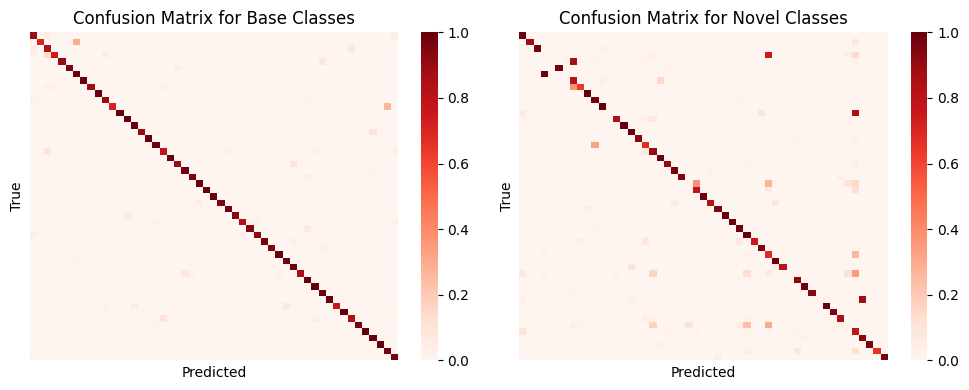

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_confusion_matrix(cm_base_ens, ax=axes[0], dataset="Base Classes")
plot_confusion_matrix(cm_novel_ens, ax=axes[1], dataset="Novel Classes")

plt.tight_layout()
plt.show()

As we can see from the result, the ensemble leads to an increment on both novel and base accuracy for visual projection layer fine-tuning. This is due to the robustness injected by the ensemble method, and also to the "implicit" control on novel classes caused by our two distillation paradigm.

# Conclusions
In this project we tried a few different approaches for fine-tuning CLIP, with some nice results!
Specifically the use of distillation can be seen as a promising way to control the performance on unseen classes, while the choice of the optimal parameter for the distillation term requires some tuning and is of fundamental importance for the obtained results.

Moreover, the ensemble approach that we proposed achieves great robustness, not only on novel classes but also a strong performance on base classes. Of course, we don't know if the improvement of using the ensemble is worth the additional training time required.

Finally, even if the distillation based fine-tuning is able to yield strong perfomances both in novel and base classes, it's limited by the choice of the hyperparameters. A next step of this work could be combining distillation losses with prompt-learning methods.